# Dual Evaluation and Improvement Ideas

In [1]:
import json
import os
import sys
import pickle
import re
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from networks import DualNet, DualNetEndToEnd, PrimalNet, PrimalNetEndToEnd, DualClassificationNetEndToEnd
import torch
from gep_config_parser import parse_config


## Helper

In [2]:
def get_dual_output(json_path, dual_path, data, if_run_test = True):
    # if run_test = True, only eval test set
    # if not, eval whole

    args = json.load(open(json_path))
    if args["dual_classification"]:
        dual_net = DualClassificationNetEndToEnd(args, data=data)
    else:
        dual_net = DualNetEndToEnd(args, data=data)
    dual_net.load_state_dict(
        torch.load(dual_path, weights_only=True),
        strict=False
    )
    dual_net.eval()


    train_size = int(args["train"] * data.X.shape[0])
    valid_size = int(args["valid"] * data.X.shape[0])

    indices = torch.arange(data.X.shape[0])

    # Split the indices
    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size+valid_size]
    test_indices = indices[train_size+valid_size:]
    len_test = len(test_indices)

    if if_run_test:
        X = data.X[test_indices]   
        mu_true  = data.opt_targets["mu_operational"][test_indices]
        lamb_true = data.opt_targets["lamb_operational"][test_indices]
        y_true = data.opt_targets["y_operational"][test_indices]
    else:
        X = data.X
        mu_true  = data.opt_targets["mu_operational"]
        lamb_true = data.opt_targets["lamb_operational"]
        y_true = data.opt_targets["y_operational"]
    with torch.no_grad():
        mu_pred, lamb_pred = dual_net(X)


    return mu_pred, lamb_pred, mu_true, lamb_true, dual_net, y_true, X

In [3]:
def print_dual_lamb_dist(data, lamb_true,  lamb_pred):
    ''' 

    '''
    n_n = data.num_n
    for node_idx in range(n_n):
        node_lambdas = lamb_true[:, node_idx]
        unique, counts = np.unique(node_lambdas, return_counts=True)
        print(f"\nNode {node_idx} class distribution:")
        for val, count in zip(unique, counts):
            print(f"  λ={val:.4f}: {count} ({100*count/len(node_lambdas):.1f}%)")

In [100]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_lambda_dist(
    data,
    dual_net,
    lamb_pred,
    lamb_true,
    title=r"Predicted vs. true $\lambda$-class distribution on the test set",
    use_title=True,
    save_name="lambda_class_distribution_professional.png",
):
    lamb_pred_np = (
        lamb_pred.detach().cpu().numpy()
        if hasattr(lamb_pred, "detach")
        else np.asarray(lamb_pred)
    )
    lamb_true_np = (
        lamb_true.detach().cpu().numpy()
        if hasattr(lamb_true, "detach")
        else np.asarray(lamb_true)
    )

    class_values = (
        dual_net.classes.detach().cpu().numpy()
        if hasattr(dual_net.classes, "detach")
        else np.asarray(dual_net.classes)
    )
    class_labels = [f"{v:.4f}" for v in class_values]

    num_nodes = data.num_n
    x = np.arange(len(class_values))
    width = 0.36

    # Make the figure taller and each panel wider
    fig, axes = plt.subplots(
        1, num_nodes,
        figsize=(5.0 * num_nodes, 4.8),
        sharey=True
    )

    if num_nodes == 1:
        axes = [axes]

    for node_idx, ax in enumerate(axes):
        node_name = data.N[node_idx]

        pred_vals = lamb_pred_np[:, node_idx]
        true_vals = lamb_true_np[:, node_idx]

        pred_counts = np.array(
            [(np.abs(pred_vals - v) < 1e-6).sum() for v in class_values],
            dtype=float
        )
        true_counts = np.array(
            [(np.abs(true_vals - v) < 1e-6).sum() for v in class_values],
            dtype=float
        )

        pred_props = pred_counts / max(pred_counts.sum(), 1.0)
        true_props = true_counts / max(true_counts.sum(), 1.0)

        ax.bar(x - width / 2, true_props, width=width, label="True", alpha=0.9)
        ax.bar(x + width / 2, pred_props, width=width, label="Predicted", alpha=0.9)

        ax.set_title(f"{node_name}", fontsize=13, pad=10, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(class_labels, rotation=35, ha="right", fontsize=11, fontweight="bold")
        ax.tick_params(axis="y", labelsize=11)


        for label in ax.get_xticklabels():
            label.set_fontweight("bold")
        for label in ax.get_yticklabels():
            label.set_fontweight("bold")

        if node_idx == 0:
            ax.set_ylabel("Proportion", fontsize=13, fontweight="bold")

        ax.set_xlabel(r"$\lambda$ class", fontsize=13, fontweight="bold")

        if node_idx == 0:
            ax.set_ylabel("Proportion", fontsize=11)

        ax.set_xlabel(r"$\lambda$ class", fontsize=11)
        ax.set_ylim(0, 1.05)

    handles, labels = axes[0].get_legend_handles_labels()

    if use_title:
        fig.suptitle(title, fontsize=15, y=0.98)
        fig.legend(
            handles, labels,
            loc="upper center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 0.92),
            fontsize=11
        )
        plt.tight_layout(rect=[0, 0, 1, 0.84])
    else:
        fig.legend(
            handles, labels,
            loc="upper center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 0.98),
            fontsize=11
        )
        plt.tight_layout(rect=[0, 0, 1, 0.88])

    save_dir = "figures"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, save_name)
    plt.savefig(save_path, dpi=400, bbox_inches="tight", pad_inches=0.03)
    plt.show()

In [101]:
import torch
import numpy as np
import pandas as pd

def compute_dual_opt_gap_percent(
    dual_model,
    data,
    X=None,
    mu_true=None,
    lamb_true=None,
    return_dataframe=False,
    eps=1e-12,
):
    """
    Compute dual optimality gap (%) for a dual model.

    Gap definition:
        gap_i (%) = (z_true_i - z_pred_i) / max(eps, |z_true_i|) * 100

    For a dual maximization problem, this should usually be >= 0
    if the predicted dual is feasible and worse than optimal.

    Args:
        dual_model: trained dual model
        data: dataset/problem object
        X: optional input tensor [N, xdim]. If None, use data.X
        mu_true: optional true dual mu tensor [N, nineq]
                 If None, use data.opt_targets["mu_operational"]
        lamb_true: optional true dual lambda tensor [N, neq]
                   If None, use data.opt_targets["lamb_operational"]
        return_dataframe: if True, also return a per-sample dataframe
        eps: numerical stabilizer

    Returns:
        results: dict with mean/median/std/max gap and objective stats
        df (optional): per-sample dataframe
    """
    dual_model.eval()

    if X is None:
        X = data.X
    if mu_true is None:
        mu_true = data.opt_targets["mu_operational"]
    if lamb_true is None:
        lamb_true = data.opt_targets["lamb_operational"]
    print(f"Computing dual optimality gap for {len(X)} samples...")
    with torch.no_grad():
        mu_pred, lamb_pred = dual_model(X)

        # Predicted and true dual objective values
        dual_obj_pred = data.dual_obj_fn(X, mu_pred, lamb_pred).reshape(-1)
        dual_obj_true = data.dual_obj_fn(X, mu_true, lamb_true).reshape(-1)

        # Gap in %
        gap_pct = (dual_obj_true - dual_obj_pred) / torch.clamp(torch.abs(dual_obj_true), min=eps) * 100.0

    gap_np = gap_pct.detach().cpu().numpy()
    pred_np = dual_obj_pred.detach().cpu().numpy()
    true_np = dual_obj_true.detach().cpu().numpy()

    results = {
        "mean_dual_opt_gap_pct": float(np.mean(gap_np)),
        "median_dual_opt_gap_pct": float(np.median(gap_np)),
        "std_dual_opt_gap_pct": float(np.std(gap_np)),
        "max_dual_opt_gap_pct": float(np.max(gap_np)),
        "min_dual_opt_gap_pct": float(np.min(gap_np)),
        "mean_pred_dual_obj": float(np.mean(pred_np)),
        "mean_true_dual_obj": float(np.mean(true_np)),
    }

    if return_dataframe:
        df = pd.DataFrame({
            "dual_obj_true": true_np,
            "dual_obj_pred": pred_np,
            "dual_opt_gap_pct": gap_np,
        })
        return results, df

    return results

# Dual Stats Evaluation

In [102]:
import json
import os
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score

from networks import DualNet, DualNetEndToEnd, DualClassificationNetEndToEnd


def evaluate_dual_only(data, dual_net, test_indices):
    """
    Evaluate only the dual surrogate.

    Returns:
        dual_opt_gap_abs_mean
        dual_opt_gap_pct_mean
        lambda_accuracy
        lambda_macro_f1
    """
    X = data.X[test_indices]

    mu_opt = data.opt_targets["mu_operational"][test_indices]
    lamb_opt = data.opt_targets["lamb_operational"][test_indices]

    dual_net.eval()
    with torch.no_grad():
        mu_pred, lamb_pred = dual_net(X)

    # ---- Dual objective optimality gap ----
    dual_opt_obj = data.dual_obj_fn(X, mu_opt, lamb_opt).detach().cpu().numpy()
    dual_pred_obj = data.dual_obj_fn(X, mu_pred, lamb_pred).detach().cpu().numpy()

    dual_opt_gap_abs = np.abs(dual_opt_obj - dual_pred_obj)
    dual_opt_gap_pct = dual_opt_gap_abs / np.maximum(np.abs(dual_opt_obj), 1e-12) * 100.0

    dual_opt_gap_abs_mean = float(np.mean(dual_opt_gap_abs))
    dual_opt_gap_pct_mean = float(np.mean(dual_opt_gap_pct))

    # ---- Lambda classification metrics ----
    # Assumes lambda targets are stored as class labels
    # and model outputs class logits/probabilities.

    lamb_pred_labels = lamb_pred.detach().cpu().numpy().astype(int)
    lamb_true_labels = lamb_opt.detach().cpu().numpy().astype(int)

    # Entrywise accuracy over all lambda outputs
    lambda_accuracy = float((lamb_pred_labels == lamb_true_labels).mean())

    # Macro-F1 over all lambda outputs flattened together
    lambda_macro_f1 = float(
        f1_score(
            lamb_true_labels.reshape(-1),
            lamb_pred_labels.reshape(-1),
            average="macro"
        )
    )
    lambda_accuracy = float(accuracy_score(lamb_true_labels, lamb_pred_labels))
    lambda_macro_f1 = float(f1_score(lamb_true_labels, lamb_pred_labels, average="macro"))

    return {
        "dual_opt_gap_abs": dual_opt_gap_abs_mean,
        "dual_opt_gap (%)": dual_opt_gap_pct_mean,
        "lambda_accuracy": lambda_accuracy,
        "lambda_macro_f1": lambda_macro_f1,
    }


def pretty_display_dual(stats_dict):
    rows = {}
    for method, metrics in stats_dict.items():
        rows[method] = {
            k: (np.mean(v) if isinstance(v, list) else v)
            for k, v in metrics.items()
        }

    df = pd.DataFrame.from_dict(rows, orient="index")

    preferred_order = [
        "dual_opt_gap_abs",
        "dual_opt_gap (%)",
        "lambda_accuracy",
        "lambda_macro_f1",
    ]
    df = df.reindex(columns=[c for c in preferred_order if c in df.columns])

    def pretty_fmt(x):
        if pd.isna(x):
            return x
        if abs(x) < 1e-3:
            return "0.000"
        return f"{x:.5f}"

    return df.style.format(pretty_fmt)


def evaluate_experiments_dual_only(
    data,
    experiment_folder,
    experiments,
    repeats=1,
):
    """
    Evaluate only dual-model quality across experiments.

    experiments: dict like
        {
            "D0": "path/to/exp0",
            "D1": "path/to/exp1",
        }
    """
    stats_dict = {}

    for name, path in experiments.items():
        stats_dict[name] = {
            "dual_opt_gap_abs": [],
            "dual_opt_gap (%)": [],
            "lambda_accuracy": [],
            "lambda_macro_f1": [],
        }

        path = os.path.join(experiment_folder, path)

        with open(os.path.join(path, "args.json"), "r") as f:
            args = json.load(f)

        train_size = int(args["train"] * data.X.shape[0])
        valid_size = int(args["valid"] * data.X.shape[0])

        indices = torch.arange(data.X.shape[0])
        test_indices = indices[train_size + valid_size:]

        args["hidden_size_factor"] = 28  # keep your override if needed

        for repeat in range(repeats):
            directory = os.path.join(path, f"repeat:{repeat}")

            # Build dual net
            if args.get("dual_alternate_loss", False):
                if args.get("dual_classification", False):
                    dual_net = DualClassificationNetEndToEnd(args, data=data)
                elif args.get("dual_completion", False):
                    dual_net = DualNetEndToEnd(args, data=data)
                else:
                    dual_net = DualNet(args, data=data)
            else:
                dual_net = DualNet(args, data=data)

            dual_net.load_state_dict(
                torch.load(os.path.join(directory, "dual_weights.pth"), weights_only=True),
                strict=False,
            )

            metrics = evaluate_dual_only(data, dual_net, test_indices)

            for k, v in metrics.items():
                stats_dict[name][k].append(v)

    return stats_dict

In [ ]:

# }
print("====Original Uniform Dataset====")
data_path = f"data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
data = pickle.load(open(data_path, 'rb')) 
experiment_folder = "outputs/PDL/ED/3Nodes-FraBelGer"
# stats_dict, const_vio_dict = evaluate_experiments_dual_only(data=data, experiment_folder=experiment_folder, experiments=experiments, repeats=1, args_file_name="config.json", absolute=True)

experiments = {
    "Baseline": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BendersBaseline",
    "SeperatePredHead": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-SeperatePredHead",
    "Supervised": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BaselineOracleClassification",
}
stats_dict = evaluate_experiments_dual_only(
    data=data,
    experiment_folder=experiment_folder,
    experiments=experiments,
    repeats=1,
)
pretty_display_dual(stats_dict)

====Original Uniform Dataset====


/Users/peterhuang/miniconda3/envs/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/peterhuang/miniconda3/envs/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/peterhuang/miniconda3/envs/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

,dual_opt_gap_abs,dual_opt_gap (%),lambda_accuracy,lambda_macro_f1
Baseline,150.90160,6.97491,0.99146,0.64281
SeperatePredHead,243.77186,11.40320,0.98932,0.63431
Supervised,134.09826,5.98503,0.99268,0.64650


In [ ]:
print("===D_CAB Dataset===")
# 
data_path = f"data/ED_Data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl"
data = pickle.load(open(data_path, 'rb')) 
experiment_folder = "outputs/PDL/ED/3Nodes-FraBelGer/Constraint"
# stats_dict, const_vio_dict = evaluate_experiments_dual_only(data=data, experiment_folder=experiment_folder, experiments=experiments, repeats=1, args_file_name="config.json", absolute=True)

experiments = {
    "Baseline": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BaselineConst2",
    "DualityGap": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-ConstDualityGap",
    "SeperatePredHead": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-D_CAB_SepHead",
    "Classify": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-OracleClassification",
    "Capacity_Trained": "../Capacity-Based/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-CapacityData-Baseline",
    "Capacity_SepHead": "../Capacity-Based/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-Capacity-SepHead",
    "Capacity_Classify":"../Capacity-Based/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-Cap-Classifier"
}
stats_dict = evaluate_experiments_dual_only(
    data=data,
    experiment_folder=experiment_folder,
    experiments=experiments,
    repeats=1,
)
pretty_display_dual(stats_dict)

===D_CAB Dataset===


,dual_opt_gap_abs,dual_opt_gap (%),lambda_accuracy,lambda_macro_f1
Baseline,1586.85887,14.39195,0.94143,0.65390
D_0_Baseline,4052.81894,117.98059,0.87797,0.62694
DualityGap,1592.70548,14.72088,0.93960,0.65320
SeperatePredHead,454.29907,13.37630,0.96309,0.93232
Classify,506.14544,12.46795,0.96156,0.94131
Capacity_Trained,13418.70072,52.71277,0.83649,0.59136
Capacity_SepHead,10051.20825,27.03479,0.84869,0.60389
Capacity_Classify,7435.65885,18.97304,0.87553,0.88182


In [105]:
print("===Capacity Bounded Dataset===")
data_path = f"data/ED_Data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_CapSobol_GenConst_ui_constraint1000_smp15_renewPerc90_NodeConst.pkl"
data_path = f"data/ED_Data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_CapSobol_GenConst_ui_constraint1000_smp15_renewMaxInvTrue_NodeConst.pkl"
data = pickle.load(open(data_path, 'rb')) 
experiment_folder = "outputs/PDL/ED/3Nodes-FraBelGer/Capacity-Based"
# stats_dict, const_vio_dict = evaluate_experiments_dual_only(data=data, experiment_folder=experiment_folder, experiments=experiments, repeats=1, args_file_name="config.json", absolute=True)

experiments = {
    "Baseline": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-CapacityData-Baseline",
    "SeperatePredHead": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-Capacity-SepHead",
    "Classify": "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-Cap-Classifier",
}
stats_dict = evaluate_experiments_dual_only(
    data=data,
    experiment_folder=experiment_folder,
    experiments=experiments,
    repeats=1,
)
pretty_display_dual(stats_dict)

===Capacity Bounded Dataset===


,dual_opt_gap_abs,dual_opt_gap (%),lambda_accuracy,lambda_macro_f1
Baseline,1443.71519,500.59524,0.96095,0.64372
SeperatePredHead,949.26008,204.29267,0.96339,0.64728
Classify,458.93704,29.54296,0.97010,0.90866


## Evaluation Dual Class Classification

In [106]:
import pickle
const_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl" # COnstrainted
orig_data_path = "data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
node_const_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewPerc90_NodeConst.pkl"
cap_data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl"

const_data = pickle.load(open(const_data_path, 'rb'))
orig_data = pickle.load(open(orig_data_path, 'rb'))
node_const_data = pickle.load(open(node_const_data_path, 'rb'))
cap_data = pickle.load(open(cap_data_path, 'rb'))

# Load trained dual net
from networks import DualClassificationNetEndToEnd
import json

base_path = "outputs/PDL/ED/3Nodes-FraBelGer"
# base_path = ""

def load_dual_net(base_path, exp_path, data):
    json_path = os.path.join(base_path, exp_path, "args.json")
    dual_path = os.path.join(base_path, exp_path, "repeat:0", "dual_weights.pth")

    args = json.load(open(json_path))
    if args["dual_classification"]:
        dual_net = DualClassificationNetEndToEnd(args, data=data)
    else:
        dual_net = DualNetEndToEnd(args, data=data)
    dual_net.load_state_dict(
        torch.load(dual_path, weights_only=True),
        strict=False
    )
    dual_net.eval()
    return dual_net,dual_path, json_path

exp_D_1_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BaselineConst2" # baseline in Const Model
#exp_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-OracleClassification"
#exp_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-ConstBaselineSeperateHead"
#exp_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-SepearteHeadNormbyObj"
exp_baseline_path = "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BendersBaseline"
#exp_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-ConstNodeBoundSupervisedDual"
cap_exp_path = "Capacity-Based/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-CapacityData-Baseline"
cap_exp_class_path = "Capacity-Based/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-Cap-Classifier"
# json_path = os.path.join(base_path, exp_path, "repeat:0", "args.json")
# exp_path = "experiment-output/ch7/3nodes/dual_model"
# exp_path = "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BaselineSeperateHead"
# json_path = os.path.join(base_path, exp_path, "args.json")
# dual_path = os.path.join(base_path, exp_path, "repeat:0", "dual_weights.pth")

# dual_path_cap = os.path.join(base_path, cap_exp_path, "repeat:0", "dual_weights.pth")
# dual_path_cap_class = os.path.join(base_path, cap_exp_class_path, "repeat:0", "dual_weights.pth")



# dual_net_baseline = load_dual_net(base_path, exp_baseline_path, orig_data)
# dual_net_cap = load_dual_net(base_path, cap_exp_path, cap_data)
# dual_net_cap_class = load_dual_net(base_path, cap_exp_class_path, cap_data)
dual_net_D_1, dual_D_1_path, json_D_1_path = load_dual_net(base_path, exp_D_1_path, const_data)
dual_net_baseline, baseline_dual_path, baseline_json_path = load_dual_net(base_path, exp_baseline_path, orig_data)
dual_net_cap, cap_dual_path, cap_json_path = load_dual_net(base_path, cap_exp_path, cap_data)
dual_net_cap_class, cap_class_dual_path, cap_class_json_path = load_dual_net(base_path, cap_exp_class_path, cap_data)   


Computing dual optimality gap for 32768 samples...


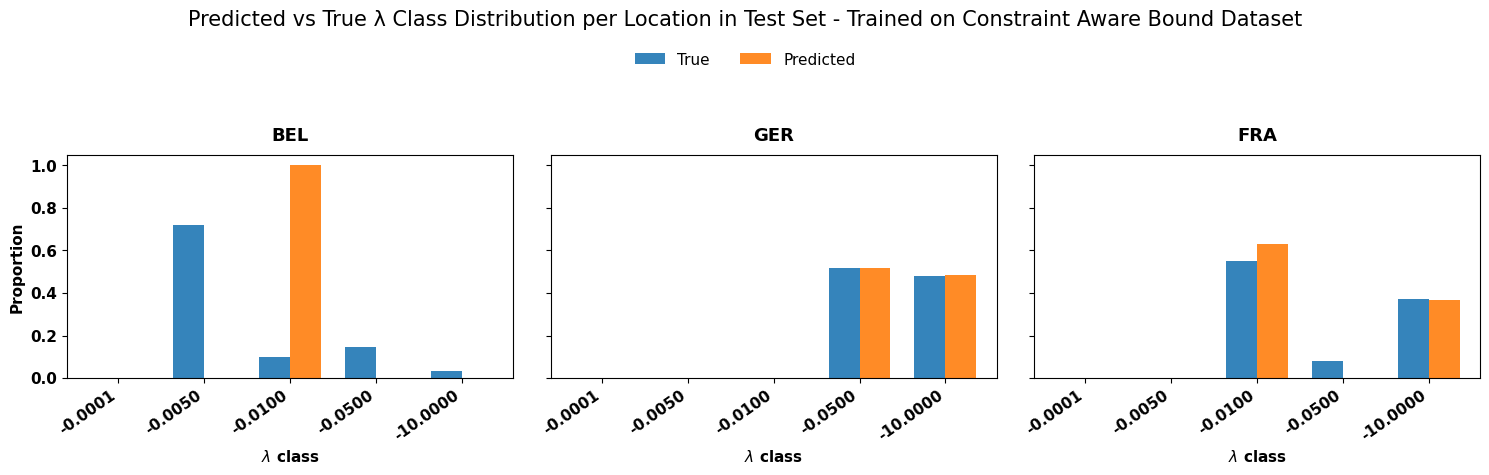

In [108]:
mu_pred, lamb_pred, mu_true, lamb_true, dual_net, y_true, X = get_dual_output(json_D_1_path, dual_D_1_path, const_data, if_run_test=True)
compute_dual_opt_gap_percent(dual_net_D_1,const_data)
plot_lambda_dist(const_data, dual_net_D_1, lamb_pred, lamb_true, 
                 title = f"Predicted vs True λ Class Distribution per Location in Test Set - Trained on Constraint Aware Bound Dataset",use_title=True)

Computing dual optimality gap for 32768 samples...


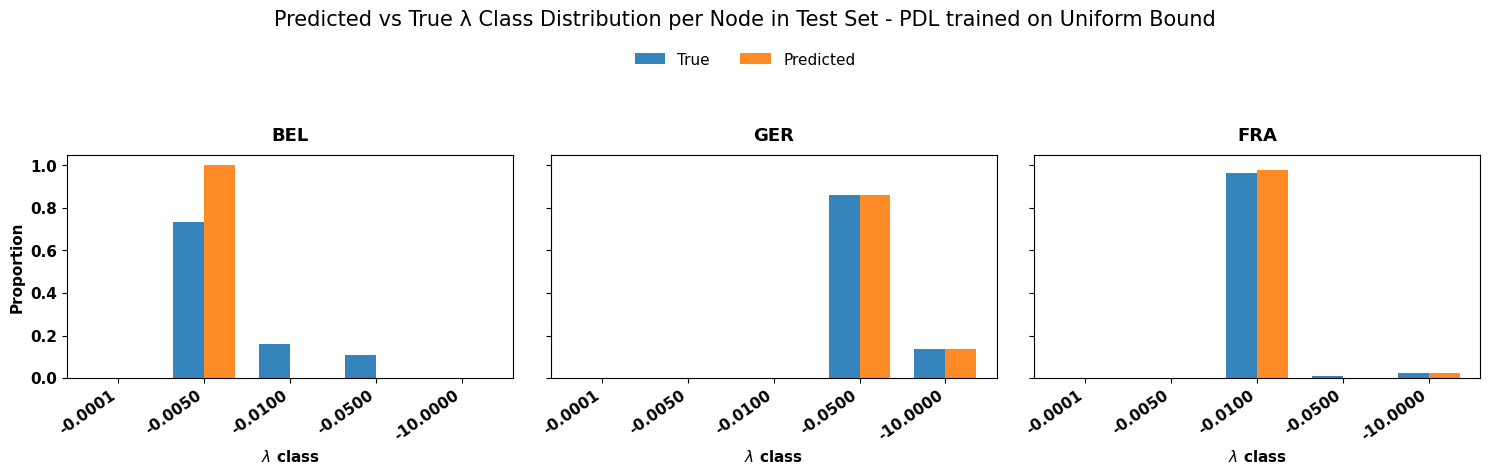

In [109]:
mu_pred, lamb_pred, mu_true, lamb_true, dual_net, y_true, X = get_dual_output(baseline_json_path, baseline_dual_path, orig_data, if_run_test=True)
compute_dual_opt_gap_percent(dual_net_baseline,orig_data)
plot_lambda_dist(orig_data, dual_net_baseline, lamb_pred, lamb_true, title = "Predicted vs True λ Class Distribution per Node in Test Set - PDL trained on Uniform Bound", use_title=True)

Computing dual optimality gap for 32768 samples...


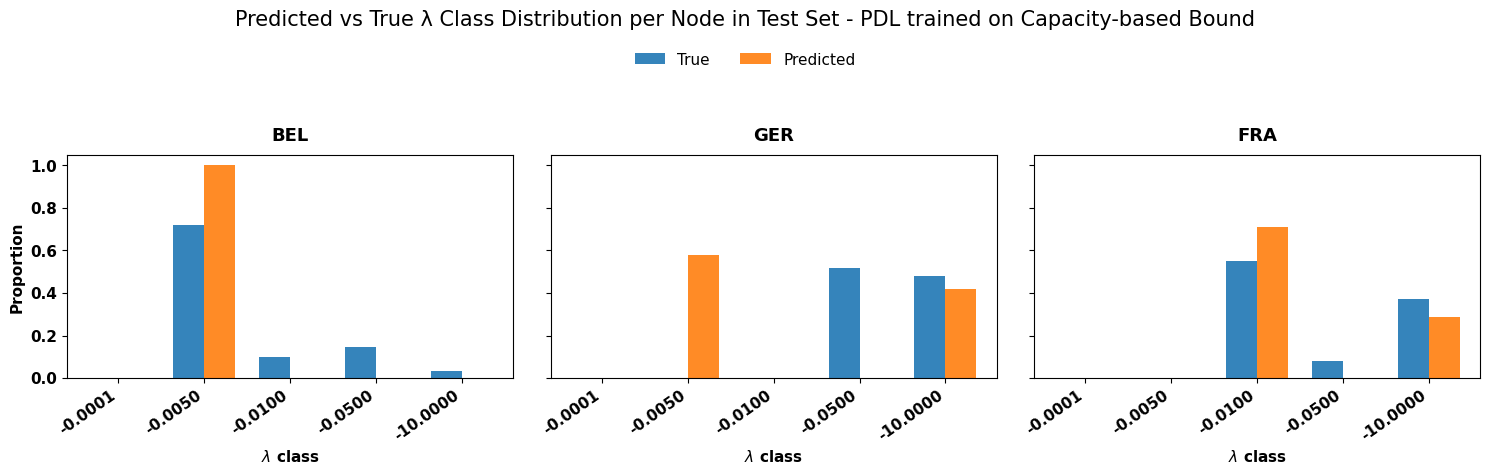

In [110]:
mu_pred, lamb_pred, mu_true, lamb_true, dual_net, y_true, X = get_dual_output(cap_json_path, cap_dual_path, cap_data, if_run_test=True)
compute_dual_opt_gap_percent(dual_net_cap,cap_data)

plot_lambda_dist(cap_data, dual_net_cap, lamb_pred, lamb_true, 
                 title = "Predicted vs True λ Class Distribution per Node in Test Set - PDL trained on Capacity-based Bound")

Computing dual optimality gap for 32768 samples...


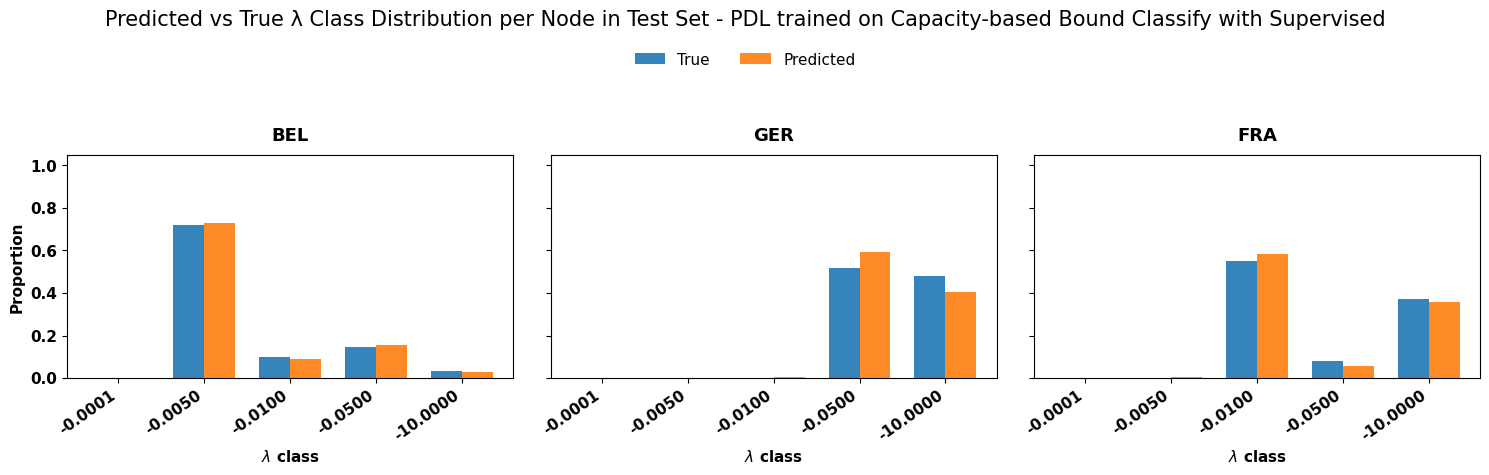

In [112]:

mu_pred, lamb_pred, mu_true, lamb_true, dual_net, y_true, X = get_dual_output(cap_class_json_path, cap_class_dual_path, cap_data, if_run_test=True)
compute_dual_opt_gap_percent(dual_net_cap_class,cap_data)

plot_lambda_dist(cap_data, dual_net_cap_class, lamb_pred, lamb_true, title = "Predicted vs True λ Class Distribution per Node in Test Set - PDL trained on Capacity-based Bound Classify with Supervised")

In [113]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def build_lambda_confusion_data(
    lamb_true,
    lamb_pred,
    class_values=None,
):
    """
    Prepare flattened true/pred arrays and class labels for confusion matrix.

    Parameters
    ----------
    lamb_true : array-like, shape [n_samples, n_nodes]
    lamb_pred : array-like, shape [n_samples, n_nodes]
    class_values : list/array-like or None
        Ordered list of class values. Example:
        [-1e-4, -5e-3, -1e-2, -5e-2, -1e1]

    Returns
    -------
    y_true_flat, y_pred_flat, class_values
    """
    y_true = _to_numpy(lamb_true)
    y_pred = _to_numpy(lamb_pred)

    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: {y_true.shape} vs {y_pred.shape}")

    if class_values is None:
        class_values = np.unique(np.concatenate([y_true.ravel(), y_pred.ravel()]))
    else:
        class_values = np.asarray(class_values)

    return y_true, y_pred, class_values

In [114]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def snap_to_nearest_class(values, class_values):
    """
    Snap each value to the nearest class value.

    Parameters
    ----------
    values : array-like, shape [... ]
    class_values : array-like, shape [n_classes]

    Returns
    -------
    snapped : np.ndarray, same shape as values
    class_idx : np.ndarray, same shape as values
    """
    values = _to_numpy(values).astype(float)
    class_values = _to_numpy(class_values).astype(float)

    flat = values.reshape(-1, 1)                      # [n, 1]
    dists = np.abs(flat - class_values.reshape(1, -1))  # [n, n_classes]
    idx = np.argmin(dists, axis=1)
    snapped = class_values[idx].reshape(values.shape)
    idx = idx.reshape(values.shape)
    return snapped, idx


def plot_lambda_confusion_matrix(
    lamb_true,
    lamb_pred,
    class_values,
    normalize="true",   # None, "true", "pred", "all"
    cmap="Blues",
    title="Overall λ confusion matrix",
    figsize=(6, 5),
    use_class_indices=False,
):
    """
    Build confusion matrix after snapping lamb_true and lamb_pred
    to nearest valid class.
    """
    class_values = _to_numpy(class_values).astype(float)

    true_snapped, true_idx = snap_to_nearest_class(lamb_true, class_values)
    pred_snapped, pred_idx = snap_to_nearest_class(lamb_pred, class_values)

    if use_class_indices:
        y_true = true_idx.ravel()
        y_pred = pred_idx.ravel()
        labels = np.arange(len(class_values))
        display_labels = [f"{c:.4g}" for c in class_values]
    else:
        y_true = true_snapped.ravel()
        y_pred = pred_snapped.ravel()
        labels = class_values
        display_labels = [f"{c:.4g}" for c in class_values]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
        normalize=normalize,
    )

    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels,
    )
    disp.plot(ax=ax, cmap=cmap, colorbar=True, values_format=".2f" if normalize else "d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return cm, true_snapped, pred_snapped

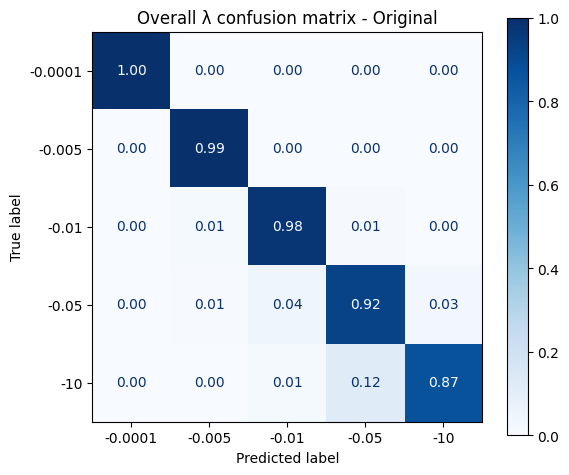

In [115]:
class_values = dual_net.classes.detach().cpu().numpy()
cm_overall, lamb_true_snap, lamb_pred_snap = plot_lambda_confusion_matrix(
    lamb_true=lamb_true,
    lamb_pred=lamb_pred,
    class_values=class_values,
    normalize="true",
    title=r"Overall λ confusion matrix - Original",
    use_class_indices=True,   # <- important
)

## Dual Model Architecture Eval

In [119]:
dual_net = dual_net_D_1
print(dual_net.classes)


tensor([-1.0000e-04, -5.0000e-03, -1.0000e-02, -5.0000e-02, -1.0000e+01])


In [120]:
import numpy as np
import pandas as pd
import torch

def build_dual_eval_table(data, lamb_pred, lamb_true, y_true=None):
    """
    Create a dataframe with per-sample predicted/true lambda regime info.

    Args:
        data: problem data object
        lamb_pred: [N, num_n]
        lamb_true: [N, num_n]
        y_true: optional primal optimal solution [N, ydim]
                if given, we compute true primal objective from it

    Returns:
        df: pandas DataFrame
    """
    lamb_pred_np = lamb_pred.detach().cpu().numpy()
    lamb_true_np = lamb_true.detach().cpu().numpy()

    df = pd.DataFrame()

    # Per-node predicted / true lambda
    for i, node in enumerate(data.N):
        df[f"pred_{node}"] = lamb_pred_np[:, i]
        df[f"true_{node}"] = lamb_true_np[:, i]

    # Count how many scarcity nodes (-10)
    df["pred_num_scarcity"] = np.sum(np.isclose(lamb_pred_np, -10.0), axis=1)
    df["true_num_scarcity"] = np.sum(np.isclose(lamb_true_np, -10.0), axis=1)

    # Full regime tuple
    df["pred_tuple"] = [tuple(row) for row in lamb_pred_np]
    df["true_tuple"] = [tuple(row) for row in lamb_true_np]

    # Non-scarcity-only tuple (only meaningful when pred_num_scarcity == 0)
    df["pred_tuple_noscarcity"] = [
        tuple(row) if np.sum(np.isclose(row, -10.0)) == 0 else None
        for row in lamb_pred_np
    ]
    df["true_tuple_noscarcity"] = [
        tuple(row) if np.sum(np.isclose(row, -10.0)) == 0 else None
        for row in lamb_true_np
    ]

    if y_true is not None:
        X = data.X[:len(df)]
        true_obj = data.obj_fn(X, y_true).detach().cpu().numpy().reshape(-1)
        df["true_obj"] = true_obj

    return df

def summarize_by_predicted_scarcity(df):
    cols = ["pred_num_scarcity", "true_num_scarcity"]
    if "true_obj" in df.columns:
        cols.append("true_obj")

    summary = (
        df.groupby("pred_num_scarcity")
          .agg(
              count=("pred_num_scarcity", "size"),
              avg_true_num_scarcity=("true_num_scarcity", "mean"),
              std_true_num_scarcity=("true_num_scarcity", "std"),
              avg_true_obj=("true_obj", "mean") if "true_obj" in df.columns else ("true_num_scarcity", "mean"),
              std_true_obj=("true_obj", "std") if "true_obj" in df.columns else ("true_num_scarcity", "std"),
          )
          .reset_index()
          .sort_values("pred_num_scarcity")
    )

    summary["pct"] = 100 * summary["count"] / summary["count"].sum()
    return summary

In [121]:
# y_true = data.opt_targets["y_operational"][test_indi]
df = build_dual_eval_table(data, lamb_pred, lamb_true, y_true=y_true)
scarcity_summary = summarize_by_predicted_scarcity(df)
scarcity_summary

,pred_num_scarcity,count,avg_true_num_scarcity,std_true_num_scarcity,avg_true_obj,std_true_obj,pct
0,0,1506,0.158035,0.417545,12327.862459,39458.898347,45.942648
1,1,1031,1.079534,0.395948,168111.634885,118887.532298,31.452105
2,2,664,2.013554,0.260172,395774.369023,211842.357110,20.256254
3,3,77,2.844156,0.488417,412262.098177,240499.868501,2.348993


In [122]:
def summarize_by_predicted_tuple(df, min_count=20):
    grouped = (
        df.groupby("pred_tuple")
          .agg(
              count=("pred_tuple", "size"),
              avg_true_num_scarcity=("true_num_scarcity", "mean"),
              avg_true_obj=("true_obj", "mean") if "true_obj" in df.columns else ("true_num_scarcity", "mean"),
              std_true_obj=("true_obj", "std") if "true_obj" in df.columns else ("true_num_scarcity", "std"),
          )
          .reset_index()
          .sort_values(["count", "avg_true_obj"], ascending=[False, False])
    )

    grouped["pct"] = 100 * grouped["count"] / grouped["count"].sum()
    return grouped[grouped["count"] >= min_count]

tuple_summary = summarize_by_predicted_tuple(df, min_count=10)
print(f"tuple summary has {len(tuple_summary)} unique predicted regimes with at least 10 samples each")
tuple_summary

tuple summary has 16 unique predicted regimes with at least 10 samples each


,pred_tuple,count,avg_true_num_scarcity,avg_true_obj,std_true_obj,pct
21,"(-0.005, -0.05, -0.01)",1034,0.176015,15059.447126,44701.893269,31.543624
16,"(-0.005, -10.0, -10.0)",494,1.995951,416821.333778,210767.809220,15.070165
18,"(-0.005, -10.0, -0.01)",414,1.024155,200121.059855,116513.978520,12.629652
19,"(-0.005, -0.05, -10.0)",335,1.197015,153894.455109,119856.066009,10.219646
15,"(-0.01, -0.05, -0.01)",193,0.005181,1787.509748,1319.744312,5.887736
5,"(-0.05, -10.0, -10.0)",154,2.071429,351345.120992,202924.317470,4.697987
10,"(-0.05, -0.05, -0.01)",97,0.010309,1889.769793,1553.410609,2.959121
13,"(-0.01, -10.0, -0.01)",96,0.968750,160812.309562,116853.757450,2.928615
8,"(-0.05, -0.05, -10.0)",96,0.968750,107948.742110,98089.616161,2.928615
20,"(-0.005, -0.05, -0.05)",89,0.483146,17089.282766,35394.468379,2.715070


In [123]:
def summarize_noscarcity_patterns(df, min_count=20):
    sub = df[df["pred_num_scarcity"] == 0].copy()

    grouped = (
        sub.groupby("pred_tuple_noscarcity")
           .agg(
               count=("pred_tuple_noscarcity", "size"),
               avg_true_obj=("true_obj", "mean"),
               std_true_obj=("true_obj", "std"),
               avg_true_num_scarcity=("true_num_scarcity", "mean"),
           )
           .reset_index()
           .sort_values(["count", "avg_true_obj"], ascending=[False, False])
    )

    grouped["pct_within_no_scarcity"] = 100 * grouped["count"] / grouped["count"].sum()
    return grouped[grouped["count"] >= min_count]

In [124]:
noscarcity_summary = summarize_noscarcity_patterns(df, min_count=1)
noscarcity_summary

,pred_tuple_noscarcity,count,avg_true_obj,std_true_obj,avg_true_num_scarcity,pct_within_no_scarcity
6,"(-0.005, -0.05, -0.01)",1034,15059.447126,44701.893269,0.176015,68.658699
4,"(-0.01, -0.05, -0.01)",193,1787.509748,1319.744312,0.005181,12.815405
1,"(-0.05, -0.05, -0.01)",97,1889.769793,1553.410609,0.010309,6.440903
5,"(-0.005, -0.05, -0.05)",89,17089.282766,35394.468379,0.483146,5.909695
0,"(-0.05, -0.05, -0.05)",71,2286.321765,795.576025,0.056338,4.714475
8,"(-0.005, -0.01, -0.01)",11,64102.421365,92373.754370,0.545455,0.730412
7,"(-0.005, -0.05, -0.005)",9,8443.525380,22679.818632,0.111111,0.597610
3,"(-0.01, -0.05, -0.05)",1,1576.902825,NaN,0.000000,0.066401
2,"(-0.05, -0.05, -0.0001)",1,25.205703,NaN,0.000000,0.066401


In [125]:
import numpy as np
import pandas as pd

def summarize_dual_error_by_true_scarcity(data, lamb_pred, lamb_true, y_true=None):
    lamb_pred_np = lamb_pred.detach().cpu().numpy()
    lamb_true_np = lamb_true.detach().cpu().numpy()

    df = pd.DataFrame({
        "true_num_scarcity": np.sum(np.isclose(lamb_true_np, -10.0), axis=1),
        "pred_num_scarcity": np.sum(np.isclose(lamb_pred_np, -10.0), axis=1),
        "tuple_exact_match": np.all(np.isclose(lamb_pred_np, lamb_true_np), axis=1).astype(float),
        "node_acc": np.mean(np.isclose(lamb_pred_np, lamb_true_np), axis=1),
        "avg_abs_lambda_err": np.mean(np.abs(lamb_pred_np - lamb_true_np), axis=1),
        "scarcity_count_match": (
            np.sum(np.isclose(lamb_true_np, -10.0), axis=1) ==
            np.sum(np.isclose(lamb_pred_np, -10.0), axis=1)
        ).astype(float)
    })

    if y_true is not None:
        X = data.X[:len(df)]
        df["true_obj"] = data.obj_fn(X, y_true).detach().cpu().numpy().reshape(-1)

    summary = (
        df.groupby("true_num_scarcity")
          .agg(
              count=("true_num_scarcity", "size"),
              avg_true_obj=("true_obj", "mean") if "true_obj" in df.columns else ("node_acc", "mean"),
              tuple_exact_acc=("tuple_exact_match", "mean"),
              avg_node_acc=("node_acc", "mean"),
              avg_abs_lambda_err=("avg_abs_lambda_err", "mean"),
              scarcity_count_acc=("scarcity_count_match", "mean"),
          )
          .reset_index()
          .sort_values("true_num_scarcity")
    )

    if "count" in summary.columns:
        summary["pct"] = 100 * summary["count"] / summary["count"].sum()

    return summary

In [127]:
y_true = data.opt_targets["y_operational"]
error_by_true_regime = summarize_dual_error_by_true_scarcity(
    data, lamb_pred, lamb_true, y_true=y_true
)
error_by_true_regime

ValueError: Length of values (32768) does not match length of index (3278)

In [128]:
import itertools
import numpy as np
import pandas as pd
import torch


def evaluate_all_lambda_combinations_for_instance(
    data,
    dual_net,
    instance_idx,
    lambda_classes,
    num_lambda_dims=None,
    dual_obj_fn=None,
    device=None,
):
    if dual_obj_fn is None:
        raise ValueError("Please pass dual_obj_fn=... to evaluate the dual objective.")

    if isinstance(lambda_classes, torch.Tensor):
        classes = lambda_classes.detach().cpu().tolist()
    else:
        classes = list(lambda_classes)

    if num_lambda_dims is None:
        if hasattr(data, "N"):
            num_lambda_dims = len(data.N)
        else:
            raise ValueError("num_lambda_dims is None and data.N does not exist.")

    if device is None:
        device = data.X.device if isinstance(data.X, torch.Tensor) else torch.device("cpu")

    # Match dtype with tensors used inside complete_duals
    dtype = data.eq_cm.dtype

    # All class combinations: e.g. 5^3 = 125
    all_combos = list(itertools.product(classes, repeat=num_lambda_dims))

    lambda_tensor = torch.tensor(all_combos, dtype=dtype, device=device)

    # Repeat the chosen instance so each lambda combo is evaluated on same instance
    X_single = data.X[instance_idx].unsqueeze(0).repeat(len(all_combos), 1).to(device=device)

    # Optional: force same dtype too
    X_single = X_single.to(dtype=data.X.dtype)

    with torch.no_grad():
        mu_tensor = dual_net.complete_duals(lambda_tensor)
        obj_tensor = dual_obj_fn(X_single, mu_tensor, lambda_tensor).reshape(-1)

    df = pd.DataFrame(all_combos, columns=[f"lambda_{i}" for i in range(num_lambda_dims)])
    df["dual_obj"] = obj_tensor.detach().cpu().numpy()

    df = df.sort_values("dual_obj", ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)

    mu_target = data.opt_targets['mu_operational'][instance_idx]
    lamb_target = data.opt_targets['lamb_operational'][instance_idx]

    opt_obj_target = dual_obj_fn(
        data.X[instance_idx].unsqueeze(0).to(device=device),
        mu_target.unsqueeze(0).to(device=device),
        lamb_target.unsqueeze(0).to(device=device)
    ).item()
    # print(f"Y optimal objective is: ")
    # print(opt_obj_target)
    return df, lambda_tensor, mu_tensor, obj_tensor

In [130]:
df_all, lambda_all, mu_all,obj_all = evaluate_all_lambda_combinations_for_instance(
    data=data,
    dual_net = dual_net,
    instance_idx=0,
    lambda_classes=dual_net.classes,
    num_lambda_dims=3,
    dual_obj_fn=data.dual_obj_fn,   # or your actual dual objective function
)

print(df_all.head(15))
# print(obj_all[0:5])


    lambda_0  lambda_1  lambda_2    dual_obj  rank
0    -0.0100   -0.0100    -0.010  349.842651     1
1    -0.0050   -0.0100    -0.010  311.993999     2
2    -0.0100   -0.0050    -0.010  306.093473     3
3    -0.0050   -0.0050    -0.010  290.144821     4
4    -0.0001   -0.0100    -0.010  264.559545     5
5    -0.0100   -0.0001    -0.010  263.219279     6
6    -0.0050   -0.0001    -0.010  247.270626     7
7    -0.0001   -0.0050    -0.010  242.710367     8
8    -0.0001   -0.0001    -0.010  221.298172     9
9    -0.0500   -0.0100    -0.010  193.431870    10
10   -0.0050   -0.0050    -0.005  182.199365    11
11   -0.0100   -0.0050    -0.005  162.648018    12
12   -0.0100   -0.0100    -0.005  156.497196    13
13   -0.0050   -0.0100    -0.005  154.148543    14
14   -0.0500   -0.0050    -0.010  149.682692    15


In [131]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter


def human_format(x, pos):
    return f"{x:,.0f}"


def plot_all_lambda_objectives_clean(df_all, title_prefix="Instance level"):
    df_plot = df_all.sort_values("dual_obj", ascending=False).reset_index(drop=True).copy()
    x = np.arange(len(df_plot))
    y = df_plot["dual_obj"].values
    gaps = y[:-1] - y[1:]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # 1) Sorted objective as step plot
    axes[0].step(x, y, where="mid")
    axes[0].scatter(x, y, s=18)
    axes[0].set_title(f"{title_prefix}\nSorted dual objective")
    axes[0].set_xlabel("Instance (order by size of dual obj)")
    axes[0].set_ylabel("Dual objective")
    axes[0].grid(True, alpha=0.3)
    axes[0].ticklabel_format(style="plain", axis="y", useOffset=False)
    axes[0].yaxis.set_major_formatter(FuncFormatter(human_format))

    # 2) Adjacent drops
    axes[1].bar(np.arange(len(gaps)), gaps)
    axes[1].set_title(f"{title_prefix}\nDrop to next rank")
    axes[1].set_xlabel("Instance (order by size of dual obj)")
    axes[1].set_ylabel("Objective drop")
    axes[1].grid(True, alpha=0.3)
    axes[1].ticklabel_format(style="plain", axis="y", useOffset=False)
    axes[1].yaxis.set_major_formatter(FuncFormatter(human_format))

    # 3) Histogram
    axes[2].hist(y, bins=min(15, len(y)))
    axes[2].set_title(f"{title_prefix}\nHistogram")
    axes[2].set_xlabel("Dual objective")
    axes[2].set_ylabel("Count")
    axes[2].grid(True, alpha=0.3)
    axes[2].ticklabel_format(style="plain", axis="x", useOffset=False)
    axes[2].xaxis.set_major_formatter(FuncFormatter(human_format))

    plt.tight_layout()
    plt.show()

    return df_plot

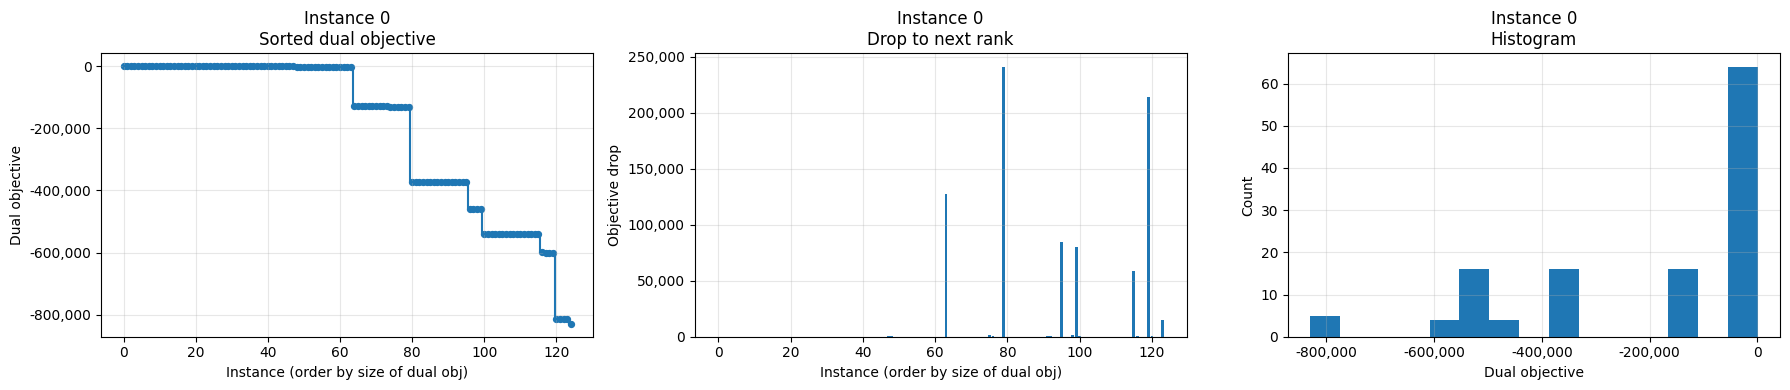

In [132]:
df_plot = plot_all_lambda_objectives_clean(df_all, title_prefix="Instance 0")

In [133]:
def summarize_by_num_minus10(df_all, scarcity_value=-10.0):
    df = df_all.copy()
    lambda_cols = [c for c in df.columns if c.startswith("lambda_")]

    df["num_minus10"] = sum(np.isclose(df[c], scarcity_value) for c in lambda_cols)

    summary = (
        df.groupby("num_minus10")["dual_obj"]
          .agg(["count", "mean", "std", "min", "max"])
          .reset_index()
          .sort_values("num_minus10")
    )
    return df, summary

In [134]:
df_with_groups, summary_minus10 = summarize_by_num_minus10(df_all, scarcity_value=-10.0)
print(summary_minus10)

   num_minus10  count           mean            std            min  \
0            0     64    -407.584743     818.994397   -1946.108783   
1            1     48 -348095.884976  170415.762363 -541088.588925   
2            2     12 -624436.436166  152418.092801 -814303.730434   
3            3      1 -829429.238315            NaN -829429.238315   

             max  
0     349.842651  
1 -129546.148336  
2 -458748.551217  
3 -829429.238315  


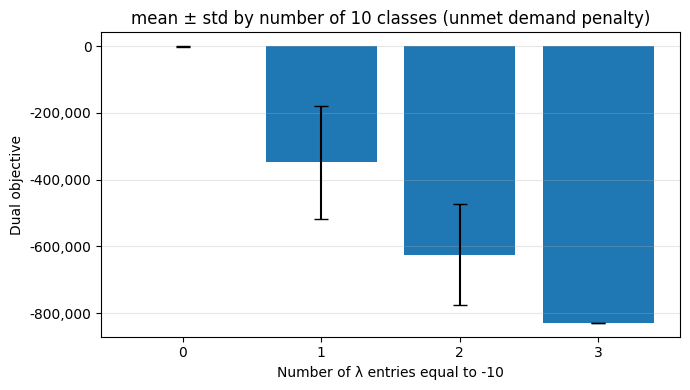

In [135]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

def human_format(x, pos):
    return f"{x:,.0f}"

def plot_mean_std_by_num_minus10(summary_df, title="Dual objective by number of -10 classes"):
    x = summary_df["num_minus10"].values
    mean = summary_df["mean"].values
    std = summary_df["std"].fillna(0).values

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x, mean, yerr=std, capsize=5)
    ax.set_title(title)
    ax.set_xlabel("Number of λ entries equal to -10")
    ax.set_ylabel("Dual objective")
    ax.set_xticks(x)
    ax.grid(True, axis="y", alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(human_format))
    plt.tight_layout()
    plt.show()

plot_mean_std_by_num_minus10(summary_minus10, title="mean ± std by number of 10 classes (unmet demand penalty)")

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_31236/35633233.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=True)


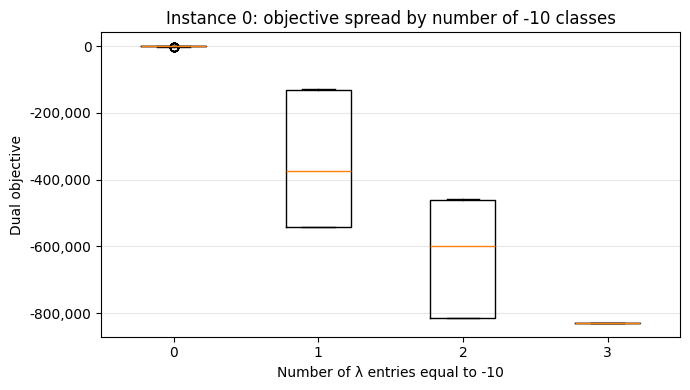

In [136]:
def plot_box_by_num_minus10(df_with_groups, title="Dual objective grouped by number of -10 classes"):
    groups = []
    labels = []
    for k in sorted(df_with_groups["num_minus10"].unique()):
        groups.append(df_with_groups.loc[df_with_groups["num_minus10"] == k, "dual_obj"].values)
        labels.append(str(k))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot(groups, labels=labels, showfliers=True)
    ax.set_title(title)
    ax.set_xlabel("Number of λ entries equal to -10")
    ax.set_ylabel("Dual objective")
    ax.grid(True, axis="y", alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(human_format))
    plt.tight_layout()
    plt.show()

plot_box_by_num_minus10(df_with_groups, title="Instance 0: objective spread by number of -10 classes")

In [137]:
def collect_minus10_summary_across_instances(
    data,
    dual_net,
    lambda_classes,
    instance_indices,
    num_lambda_dims=3,
    dual_obj_fn=None,
    scarcity_value=-10.0,
):
    rows = []

    for idx in instance_indices:
        df_all, lambda_all, mu_all, obj_all = evaluate_all_lambda_combinations_for_instance(
            data=data,
            dual_net=dual_net,
            instance_idx=idx,
            lambda_classes=lambda_classes,
            num_lambda_dims=num_lambda_dims,
            dual_obj_fn=dual_obj_fn,
        )

        lambda_cols = [c for c in df_all.columns if c.startswith("lambda_")]
        df_all["num_minus10"] = sum(np.isclose(df_all[c], scarcity_value) for c in lambda_cols)
        df_all["instance_idx"] = idx

        rows.append(df_all[["instance_idx", "dual_obj", "num_minus10"]])

    out = pd.concat(rows, ignore_index=True)
    return out

In [138]:
all_grouped = collect_minus10_summary_across_instances(
    data=data,
    dual_net=dual_net,
    lambda_classes=dual_net.classes,
    instance_indices=range(20),   # example
    num_lambda_dims=3,
    dual_obj_fn=data.dual_obj_fn,
    scarcity_value=float(dual_net.classes.min()),
)

   num_minus10  count           mean            std           min  \
0            0   1280    -114.095341    1148.086642 -4.497886e+03   
1            1    960 -296237.468284  317622.458793 -9.758571e+05   
2            2    240 -521013.092185  496998.270553 -1.792020e+06   
3            3     20 -674440.967045  683290.477811 -1.915528e+06   

             max  
0    4516.773364  
1  351267.246306  
2  734271.881335  
3  703616.786307  


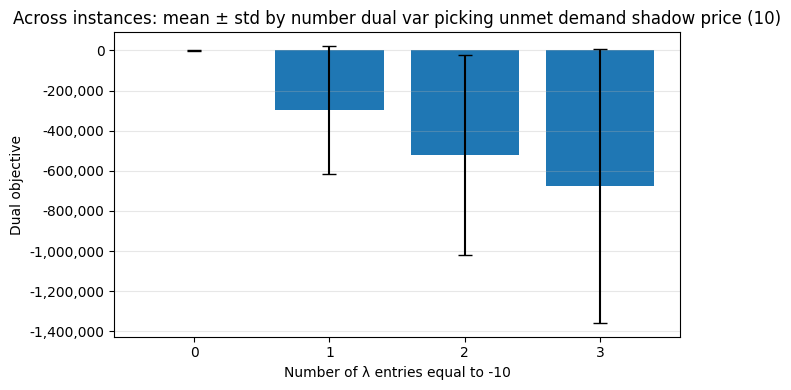

In [139]:
agg_summary = (
    all_grouped.groupby("num_minus10")["dual_obj"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
    .sort_values("num_minus10")
)

print(agg_summary)
plot_mean_std_by_num_minus10(agg_summary, title="Across instances: mean ± std by number dual var picking unmet demand shadow price (10)")

In [140]:
for i in data.G:
    print(f"{i} cost: {data.pVarCost[i]}")
print(f"Unmet Demand penalty: 10")

('BEL', 'WindOff') cost: 0.005
('BEL', 'Gas') cost: 0.05
('GER', 'Gas') cost: 0.05
('GER', 'SunPV') cost: 0.0001
('FRA', 'Nuclear') cost: 0.01
('FRA', 'SunPV') cost: 0.0001
Unmet Demand penalty: 10


## Evaluate dual performance based on input feat 

Two scnearios is difficult for dual
- High standard deviation and high range of renewable availabliity especially the cheapest one
- Low demand  or low demand to avaiabliity ratio

In [142]:
mu_pred, lamb_pred, mu_true, lamb_true, dual_net, y_true, X = get_dual_output(json_D_1_path, dual_D_1_path, data, if_run_test=True)

In [146]:
print(X.shape)
print(y_true.shape)

opt_gap = compute_dual_opt_gap_percent(
    dual_model=dual_net,
    data=data,
    X=X,
    mu_true=mu_true,
    lamb_true=lamb_true,
)
opt_gap

torch.Size([3278, 9])
torch.Size([3278, 12])
Computing dual optimality gap for 3278 samples...


{'mean_dual_opt_gap_pct': 1695.8214822827936,
 'median_dual_opt_gap_pct': 5.55127281442822,
 'std_dual_opt_gap_pct': 5409.056841452209,
 'max_dual_opt_gap_pct': 49403.25088472673,
 'min_dual_opt_gap_pct': 0.0,
 'mean_pred_dual_obj': 37054.89842410267,
 'mean_true_dual_obj': 38548.61508831735}

In [ ]:
# can get the loc, gen, time 's avaiabliity by doing data.pGenAva.get((*g, t), 1.0) for the data
# Demand is the first len(data.N) feature of X

['BEL', 'GER', 'FRA']

In [147]:

def compute_dual_gap_pct_per_sample_from_outputs(
    data,
    X,
    mu_pred,
    lamb_pred,
    mu_true,
    lamb_true,
):
    """
    Compute per-sample dual optimality gap percentage using predicted and true dual outputs.

    Gap definition:
        abs(pred_dual_obj - true_dual_obj) / max(abs(true_dual_obj), 1e-12) * 100

    Returns
    -------
    dual_gap_pct : np.ndarray, shape [n_samples]
    pred_dual_obj : np.ndarray
    true_dual_obj : np.ndarray
    """
    if isinstance(mu_pred, torch.Tensor):
        mu_pred = mu_pred.detach().cpu()
    if isinstance(lamb_pred, torch.Tensor):
        lamb_pred = lamb_pred.detach().cpu()
    if isinstance(mu_true, torch.Tensor):
        mu_true = mu_true.detach().cpu()
    if isinstance(lamb_true, torch.Tensor):
        lamb_true = lamb_true.detach().cpu()

    # Reuse your existing dual objective function if you have one.
    # Replace this block if your project already has a helper like dual_obj_fn(...)
    pred_dual_obj = data.dual_obj_fn(X, mu_pred, lamb_pred).detach().cpu().numpy()
    true_dual_obj = data.dual_obj_fn(X, mu_true, lamb_true).detach().cpu().numpy()

    dual_gap_pct = (
        np.abs(pred_dual_obj - true_dual_obj)
        / np.maximum(np.abs(true_dual_obj), 1e-12)
        * 100.0
    )

    return dual_gap_pct, pred_dual_obj, true_dual_obj

def build_dual_gap_vs_demand_df(
    X,
    data,
    dual_gap_pct,
    pred_dual_obj=None,
    true_dual_obj=None,
):
    """
    Build a dataframe with:
      - total_demand
      - total_available
      - demand_to_total_available
      - dual_gap_pct

    Assumptions
    -----------
    X[:, :len(data.N)] = nodal demands
    X[:, len(data.N):] = generator-related availability/capacity features
    """
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)

    n_nodes = len(data.N)

    demand_block = X_np[:, :n_nodes]
    avail_block = X_np[:, n_nodes:]

    total_demand = demand_block.sum(axis=1)
    total_available = avail_block.sum(axis=1)
    demand_to_total_available = total_demand / np.maximum(total_available, 1e-12)

    df = pd.DataFrame({
        "sample_idx": np.arange(X_np.shape[0]),
        "total_demand": total_demand,
        "total_available": total_available,
        "demand_to_total_available": demand_to_total_available,
        "dual_gap_pct": np.asarray(dual_gap_pct),
    })

    if pred_dual_obj is not None:
        df["pred_dual_obj"] = np.asarray(pred_dual_obj)
    if true_dual_obj is not None:
        df["true_dual_obj"] = np.asarray(true_dual_obj)

    return df

In [148]:
def plot_dual_gap_vs_demand_features(
    df,
    annotate=False,
    sample_col="sample_idx",
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_specs = [
        ("total_demand", "dual_gap_pct", "Dual gap vs total demand"),
        ("demand_to_total_available", "dual_gap_pct", "Dual gap vs demand / total availability"),
    ]

    for ax, (xcol, ycol, title) in zip(axes, plot_specs):
        ax.scatter(df[xcol], df[ycol], alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.grid(True, alpha=0.3)

        if annotate:
            for _, row in df.iterrows():
                ax.annotate(
                    str(int(row[sample_col])),
                    (row[xcol], row[ycol]),
                    fontsize=7,
                    xytext=(3, 3),
                    textcoords="offset points",
                )

    plt.tight_layout()
    plt.show()

   sample_idx   total_demand  total_available  demand_to_total_available  \
0           0   35799.185494    124878.762819                   0.286672   
1           1   82585.922422    126078.528354                   0.655036   
2           2   72575.090225     94659.941670                   0.766693   
3           3  101728.351386    264047.355442                   0.385266   
4           4  114931.397389    230135.406153                   0.499408   

   dual_gap_pct  pred_dual_obj  true_dual_obj  
0      4.756148     668.975254     702.381557  
1    239.218787    -225.287086     161.822330  
2      5.396319     521.902364     551.672366  
3    284.016423    -135.108067      73.421744  
4      2.135563     899.409299     919.035890  


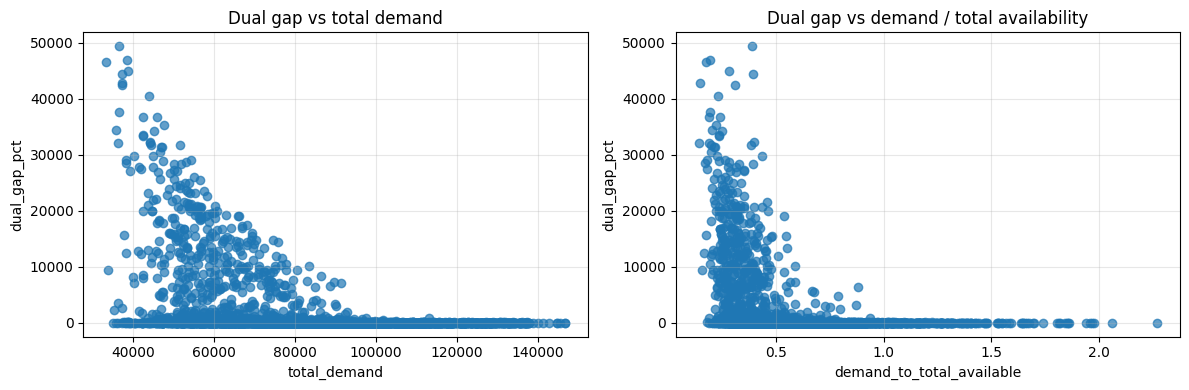

In [149]:
# If data.dual_obj exists:
dual_gap_pct, pred_dual_obj, true_dual_obj = compute_dual_gap_pct_per_sample_from_outputs(
    data=data,
    X = X,
    mu_pred=mu_pred,
    lamb_pred=lamb_pred,
    mu_true=mu_true,
    lamb_true=lamb_true,
)

df_dual_gap = build_dual_gap_vs_demand_df(
    X=X,
    data=data,
    dual_gap_pct=dual_gap_pct,
    pred_dual_obj=pred_dual_obj,
    true_dual_obj=true_dual_obj,
)

print(df_dual_gap.head())

plot_dual_gap_vs_demand_features(
    df_dual_gap,
    annotate=False,   # True if you want sample labels
)

In [150]:
import numpy as np
import matplotlib.pyplot as plt


def plot_dual_gap_vs_features_better(
    df,
    feature_cols=("total_demand", "demand_to_total_available"),
    target_col="dual_gap_pct",
    clip_percentile=99,
    bins=20,
):
    """
    Makes 3 views for each feature:
      1) raw scatter with log y
      2) zoomed scatter with top outliers clipped
      3) binned median trend
    """
    y = df[target_col].values.astype(float)
    y_clip = np.percentile(y, clip_percentile)

    n_features = len(feature_cols)
    fig, axes = plt.subplots(
        nrows=3,
        ncols=n_features,
        figsize=(6 * n_features, 11),
        squeeze=False,
    )

    for j, col in enumerate(feature_cols):
        x = df[col].values.astype(float)

        # -------------------------
        # 1) Raw scatter with log y
        # -------------------------
        ax = axes[0, j]
        ax.scatter(x, y + 1e-6, alpha=0.35, s=20)
        ax.set_yscale("log")
        ax.set_title(f"{target_col} vs {col} (log y)")
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)
        ax.grid(True, alpha=0.3)

        # -------------------------
        # 2) Zoomed scatter
        # -------------------------
        ax = axes[1, j]
        mask = y <= y_clip
        ax.scatter(x[mask], y[mask], alpha=0.35, s=20)
        ax.set_title(f"{target_col} vs {col} (<= p{clip_percentile})")
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)
        ax.grid(True, alpha=0.3)

        # -------------------------
        # 3) Binned median trend
        # -------------------------
        ax = axes[2, j]

        # sort by x
        order = np.argsort(x)
        x_sorted = x[order]
        y_sorted = y[order]

        # equal-count bins
        x_bins = np.array_split(x_sorted, bins)
        y_bins = np.array_split(y_sorted, bins)

        x_mid = np.array([np.mean(b) for b in x_bins if len(b) > 0])
        y_med = np.array([np.median(b) for b in y_bins if len(b) > 0])
        y_mean = np.array([np.mean(b) for b in y_bins if len(b) > 0])

        ax.plot(x_mid, y_med, marker="o", label="Median dual gap")
        ax.plot(x_mid, y_mean, marker="s", label="Mean dual gap")
        ax.set_title(f"Binned trend: {target_col} vs {col}")
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

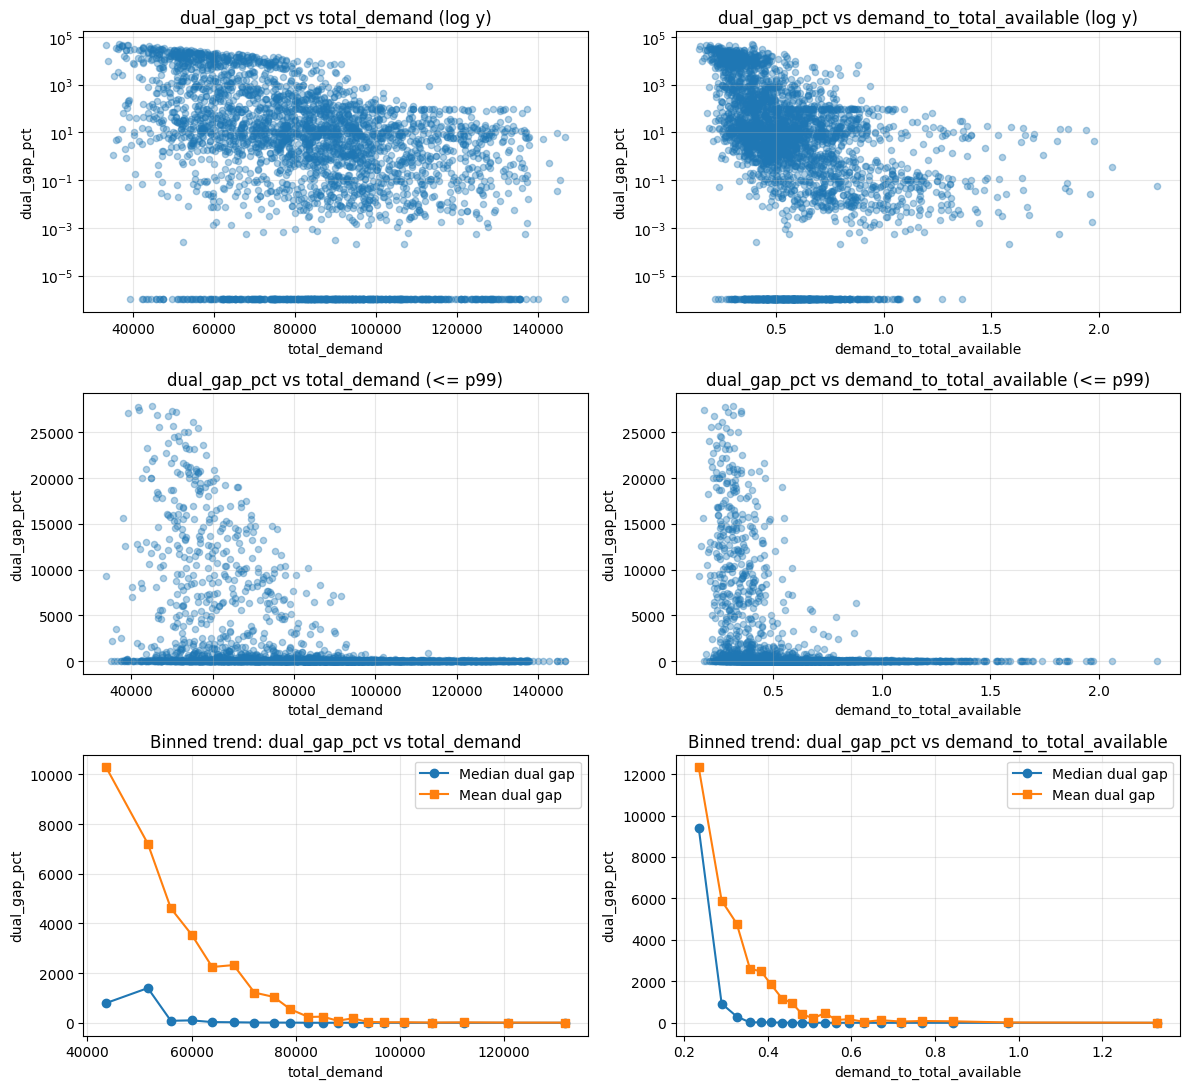

In [151]:
plot_dual_gap_vs_features_better(
    df_dual_gap,
    feature_cols=("total_demand", "demand_to_total_available"),
    target_col="dual_gap_pct",
    clip_percentile=99,
    bins=20,
)

In [51]:
dual_net.classes

tensor([-1.0000e-04, -5.0000e-03, -1.0000e-02, -5.0000e-02, -1.0000e+01])

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def analyze_dual_gap_by_num_lambda_at_minus10(
    lamb_true,
    dual_gap_pct,
    target_class_value=-10.0,
    max_count_to_show=3,
    atol=1e-8,
):
    """
    Group samples by how many lambda entries equal the target class value
    (default: -10.0), then compare dual gap across groups.

    Parameters
    ----------
    lamb_true : torch.Tensor or np.ndarray, shape [n_samples, n_lambda]
    dual_gap_pct : array-like, shape [n_samples]
    target_class_value : float
        The lambda class value to count, default -10.0.
    max_count_to_show : int
        Show only counts 0, 1, ..., max_count_to_show.
    atol : float
        Tolerance for equality check.

    Returns
    -------
    df_plot : pd.DataFrame
        Per-sample dataframe with lambda count and dual gap.
    summary : pd.DataFrame
        Grouped summary stats.
    """
    if isinstance(lamb_true, torch.Tensor):
        lamb_true = lamb_true.detach().cpu().numpy()
    else:
        lamb_true = np.asarray(lamb_true)

    dual_gap_pct = np.asarray(dual_gap_pct).reshape(-1)

    if lamb_true.shape[0] != len(dual_gap_pct):
        raise ValueError("lamb_true and dual_gap_pct must have same number of samples")

    # Count how many lambda values are equal to -10 for each sample
    num_lambda_at_target = np.sum(np.isclose(lamb_true, target_class_value, atol=atol), axis=1)

    df_plot = pd.DataFrame({
        "sample_idx": np.arange(len(dual_gap_pct)),
        "num_lambda_at_target": num_lambda_at_target,
        "dual_gap_pct": dual_gap_pct,
    })

    # Keep only 0..max_count_to_show
    df_plot = df_plot[df_plot["num_lambda_at_target"].between(0, max_count_to_show)].copy()

    summary = (
        df_plot.groupby("num_lambda_at_target")["dual_gap_pct"]
        .agg(["count", "mean", "median", "std", "max"])
        .reset_index()
    )

    return df_plot, summary

In [153]:
def plot_dual_gap_by_lambda_count_box(
    df_plot,
    title="Dual gap vs number of λ values equal to -10",
):
    groups = sorted(df_plot["num_lambda_at_target"].unique())
    data = [
        df_plot.loc[df_plot["num_lambda_at_target"] == g, "dual_gap_pct"].values
        for g in groups
    ]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.boxplot(data, labels=groups, showfliers=False)

    # jittered raw points
    rng = np.random.default_rng(0)
    for i, g in enumerate(groups, start=1):
        y = df_plot.loc[df_plot["num_lambda_at_target"] == g, "dual_gap_pct"].values
        x = i + rng.uniform(-0.08, 0.08, size=len(y))
        ax.scatter(x, y, alpha=0.25, s=18)

    ax.set_xlabel("Number of λ entries equal to -10")
    ax.set_ylabel("dual_gap_pct")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_dual_gap_by_lambda_count_summary(
    summary,
    title="Grouped dual gap statistics by number of λ entries equal to -10",
):
    x = summary["num_lambda_at_target"].values
    mean_vals = summary["mean"].values
    median_vals = summary["median"].values

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    # Mean
    axes[0].bar(x, mean_vals)
    for xi, yi in zip(x, mean_vals):
        axes[0].text(xi, yi, f"{yi:.2f}", ha="center", va="bottom", fontsize=9)
    axes[0].set_title("Mean dual gap")
    axes[0].set_xlabel("Number of λ entries equal to -10")
    axes[0].set_ylabel("dual_gap_pct")
    axes[0].grid(True, axis="y", alpha=0.3)

    # Median
    axes[1].bar(x, median_vals)
    for xi, yi in zip(x, median_vals):
        axes[1].text(xi, yi, f"{yi:.2f}", ha="center", va="bottom", fontsize=9)
    axes[1].set_title("Median dual gap")
    axes[1].set_xlabel("Number of λ entries equal to -10")
    axes[1].set_ylabel("dual_gap_pct")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    

   num_lambda_at_target  count         mean     median          std  \
0                     0   2515  2206.686523  10.944302  6085.011040   
1                     1    574    11.473984   0.029019    30.475251   
2                     2    141    11.239316   0.087143    30.181112   
3                     3     48    19.070908   8.694506    26.158004   

            max  
0  49403.250885  
1    114.415055  
2    220.573541  
3     97.412380  


/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_31236/700607131.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showfliers=False)


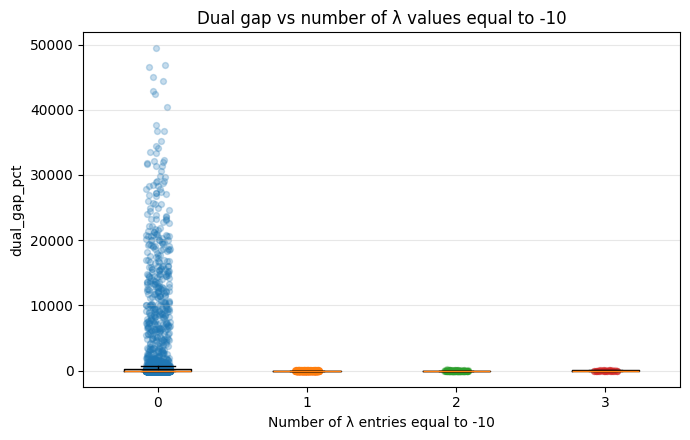

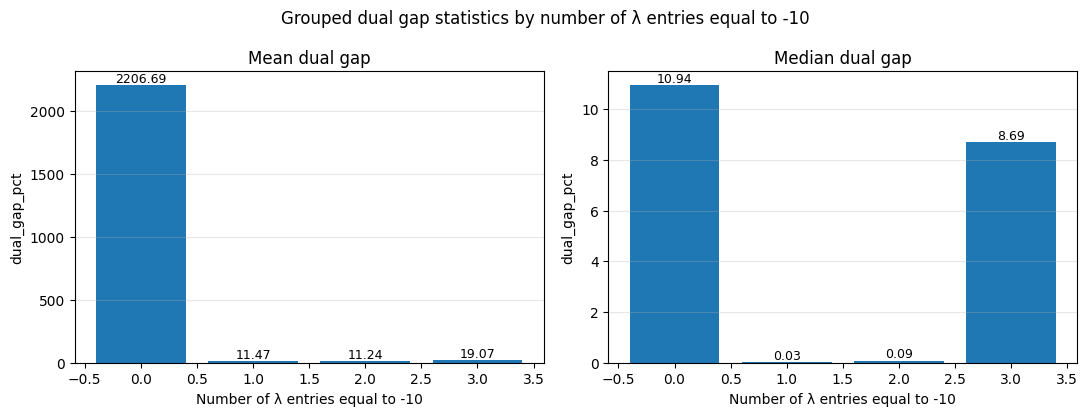

In [154]:
df_lambda10, summary_lambda10 = analyze_dual_gap_by_num_lambda_at_minus10(
    lamb_true=lamb_true,
    dual_gap_pct=df_dual_gap["dual_gap_pct"].values,   # or your dual_gap_pct array directly
    target_class_value=-10.0,
    max_count_to_show=3,
)

print(summary_lambda10)

plot_dual_gap_by_lambda_count_box(df_lambda10)
plot_dual_gap_by_lambda_count_summary(summary_lambda10)

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_31236/3198598198.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showfliers=False)


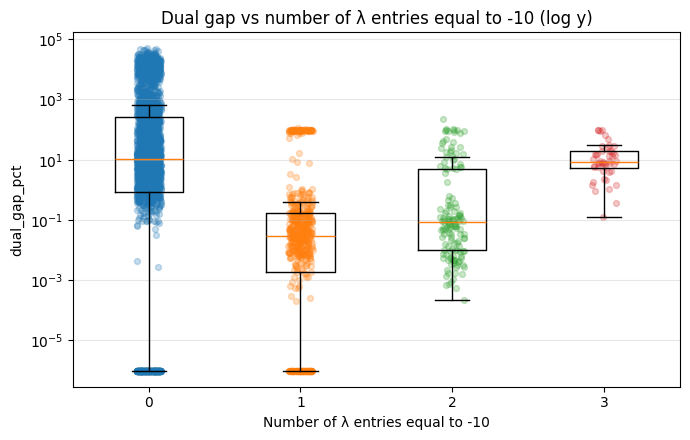

In [155]:
def plot_dual_gap_by_lambda_count_box_log(
    df_plot,
    title="Dual gap vs number of λ entries equal to -10 (log y)",
):
    groups = sorted(df_plot["num_lambda_at_target"].unique())
    data = [
        df_plot.loc[df_plot["num_lambda_at_target"] == g, "dual_gap_pct"].values + 1e-6
        for g in groups
    ]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.boxplot(data, labels=groups, showfliers=False)

    rng = np.random.default_rng(0)
    for i, g in enumerate(groups, start=1):
        y = df_plot.loc[df_plot["num_lambda_at_target"] == g, "dual_gap_pct"].values + 1e-6
        x = i + rng.uniform(-0.08, 0.08, size=len(y))
        ax.scatter(x, y, alpha=0.25, s=18)

    ax.set_yscale("log")
    ax.set_xlabel("Number of λ entries equal to -10")
    ax.set_ylabel("dual_gap_pct")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_dual_gap_by_lambda_count_box_log(df_lambda10)

In [156]:
print(X.shape)
print(data.G)
print(data.N)

torch.Size([3278, 9])
[('BEL', 'WindOff'), ('BEL', 'Gas'), ('GER', 'Gas'), ('GER', 'SunPV'), ('FRA', 'Nuclear'), ('FRA', 'SunPV')]
['BEL', 'GER', 'FRA']


In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def build_local_dual_gap_feature_df(X, data, dual_gap_pct):
    """
    Build per-sample dataframe with:
      - nodal demand
      - nodal local available capacity
      - nodal demand/local-availability ratio
      - renewable generator availabilities from X
      - dual gap

    Assumptions
    -----------
    X columns:
      first len(data.N) columns = nodal demands in order data.N
      next len(data.G) columns = generator available capacities in order data.G
    """
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)

    dual_gap_pct = np.asarray(dual_gap_pct).reshape(-1)

    n_nodes = len(data.N)
    n_gens = len(data.G)

    if X_np.shape[1] != n_nodes + n_gens:
        raise ValueError(
            f"Expected X to have {n_nodes + n_gens} columns, got {X_np.shape[1]}"
        )

    df = pd.DataFrame({
        "sample_idx": np.arange(X_np.shape[0]),
        "dual_gap_pct": dual_gap_pct,
    })

    # -------------------------
    # Nodal demands
    # -------------------------
    for i, n in enumerate(data.N):
        df[f"demand_{n}"] = X_np[:, i]

    # -------------------------
    # Generator available capacities
    # -------------------------
    gen_offset = n_nodes
    for j, g in enumerate(data.G):
        node, tech = g
        col = f"availcap_{node}_{tech}"
        df[col] = X_np[:, gen_offset + j]

    # -------------------------
    # Local total available cap per node
    # -------------------------
    for n in data.N:
        gen_cols_n = [f"availcap_{node}_{tech}" for (node, tech) in data.G if node == n]
        df[f"local_availcap_{n}"] = df[gen_cols_n].sum(axis=1)
        df[f"demand_to_local_avail_{n}"] = (
            df[f"demand_{n}"] / np.maximum(df[f"local_availcap_{n}"], 1e-12)
        )

    # -------------------------
    # Renewable-only columns
    # -------------------------
    renewable_cols = []
    for (node, tech) in data.G:
        if tech.lower() in {"windoff", "windon", "sunpv"}:
            col = f"availcap_{node}_{tech}"
            renewable_cols.append(col)

    # system-level renewable features
    if renewable_cols:
        df["total_renewable_availcap"] = df[renewable_cols].sum(axis=1)
        df["mean_renewable_availcap"] = df[renewable_cols].mean(axis=1)
        df["std_renewable_availcap"] = df[renewable_cols].std(axis=1)

    return df

In [158]:
def plot_local_features_vs_dual_gap(
    df,
    data,
    annotate=False,
):
    """
    Plot:
      - demand_NODE vs dual gap
      - demand_to_local_avail_NODE vs dual gap
    """
    node_cols_1 = [f"demand_{n}" for n in data.N]
    node_cols_2 = [f"demand_to_local_avail_{n}" for n in data.N]

    fig, axes = plt.subplots(2, len(data.N), figsize=(5 * len(data.N), 8), squeeze=False)

    for j, n in enumerate(data.N):
        # Row 1: demand
        xcol = f"demand_{n}"
        axes[0, j].scatter(df[xcol], df["dual_gap_pct"], alpha=0.35, s=18)
        axes[0, j].set_title(f"Dual gap vs demand at {n}")
        axes[0, j].set_xlabel(xcol)
        axes[0, j].set_ylabel("dual_gap_pct")
        axes[0, j].grid(True, alpha=0.3)

        # Row 2: demand / local avail
        xcol = f"demand_to_local_avail_{n}"
        axes[1, j].scatter(df[xcol], df["dual_gap_pct"], alpha=0.35, s=18)
        axes[1, j].set_title(f"Dual gap vs demand/local avail at {n}")
        axes[1, j].set_xlabel(xcol)
        axes[1, j].set_ylabel("dual_gap_pct")
        axes[1, j].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [159]:
def plot_renewables_vs_dual_gap(df, log_y=False):
    renewable_cols = [
        "availcap_BEL_WindOff",
        "availcap_GER_SunPV",
        "availcap_FRA_SunPV",
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), squeeze=False)

    for ax, col in zip(axes[0], renewable_cols):
        y = df["dual_gap_pct"].to_numpy()

        if log_y:
            y = y + 1e-6  # avoid log(0)

        ax.scatter(df[col], y, alpha=0.35, s=18)
        ax.set_title(f"Dual gap vs {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("dual_gap_pct")

        if log_y:
            ax.set_yscale("log")

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
def plot_high_low_renewable_dual_gap_box(df):
    renewable_cols = [
        "availcap_BEL_WindOff",
        "availcap_GER_SunPV",
        "availcap_FRA_SunPV",
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), squeeze=False)

    rng = np.random.default_rng(0)

    for ax, col in zip(axes[0], renewable_cols):
        threshold = df[col].median()

        low_mask = df[col] <= threshold
        high_mask = df[col] > threshold

        low_vals = df.loc[low_mask, "dual_gap_pct"].values
        high_vals = df.loc[high_mask, "dual_gap_pct"].values

        ax.boxplot([low_vals, high_vals], labels=["Low", "High"], showfliers=False)

        # jitter raw points
        for i, vals in enumerate([low_vals, high_vals], start=1):
            x = i + rng.uniform(-0.08, 0.08, size=len(vals))
            ax.scatter(x, vals, alpha=0.2, s=14)

        ax.set_title(f"Dual gap by {col}\n(low/high split at median)")
        ax.set_ylabel("dual_gap_pct")
        ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

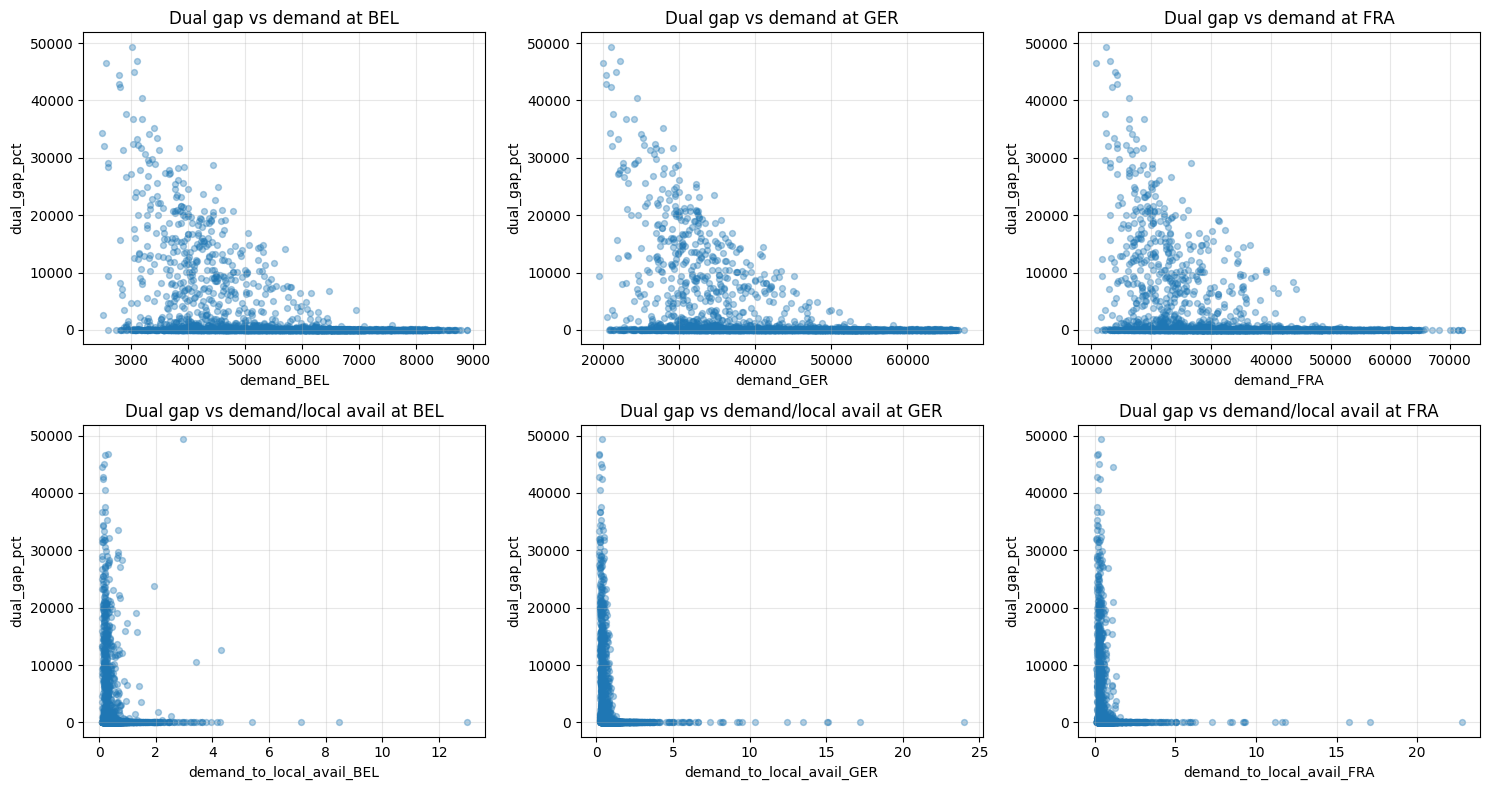

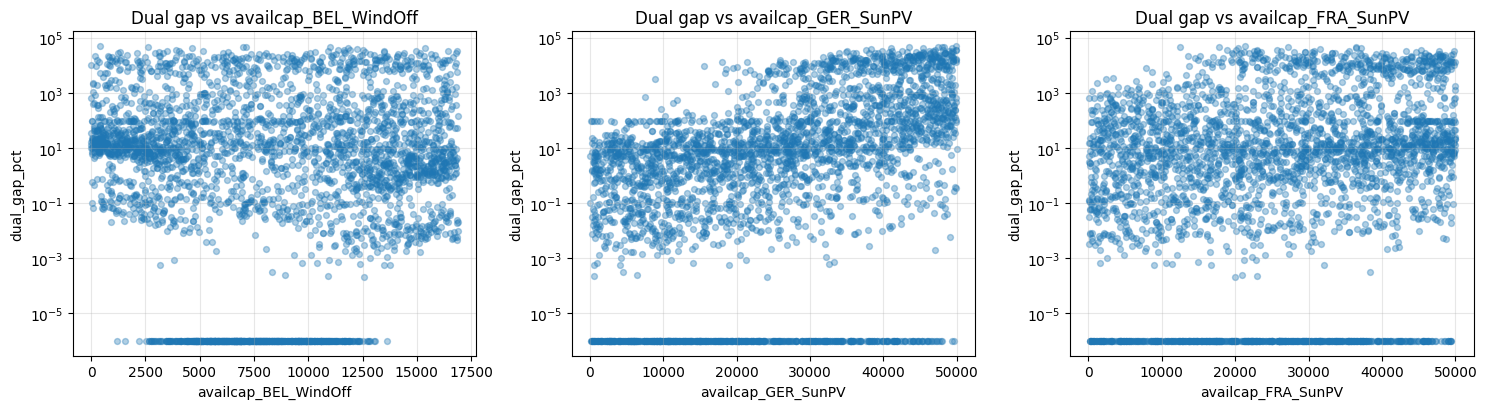

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_31236/2209119820.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([low_vals, high_vals], labels=["Low", "High"], showfliers=False)
/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_31236/2209119820.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([low_vals, high_vals], labels=["Low", "High"], showfliers=False)
/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_31236/2209119820.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([low_vals, high_vals], labels=["Low", "High"], showfliers=False)


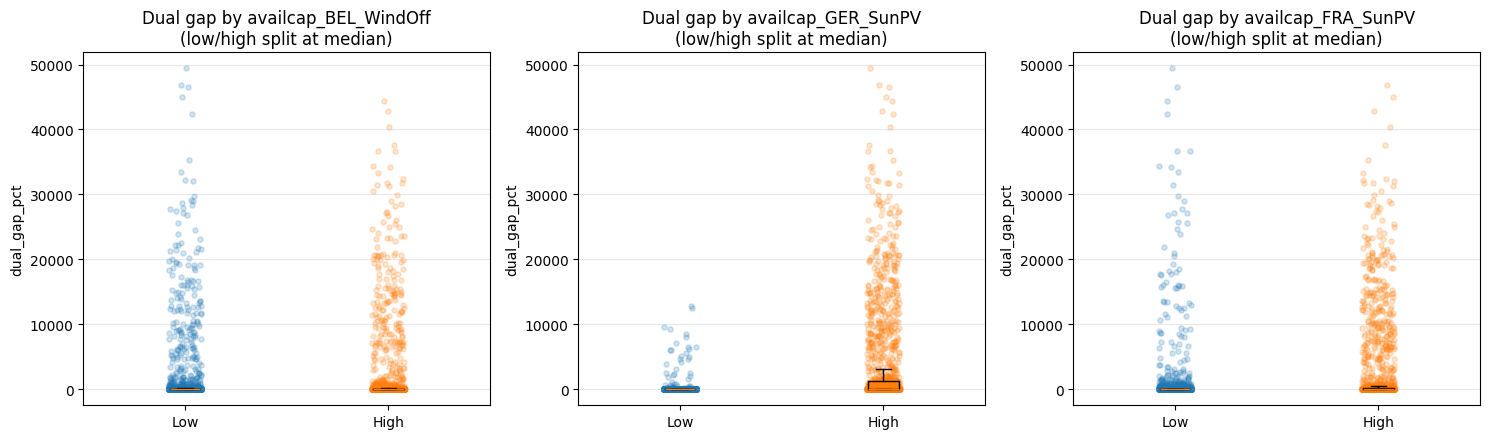

In [160]:
df_local = build_local_dual_gap_feature_df(X, data, df_dual_gap["dual_gap_pct"].values)
plot_local_features_vs_dual_gap(df_local, data)
plot_renewables_vs_dual_gap(df_local, log_y=True)
plot_high_low_renewable_dual_gap_box(df_local)

<Figure size 800x500 with 0 Axes>

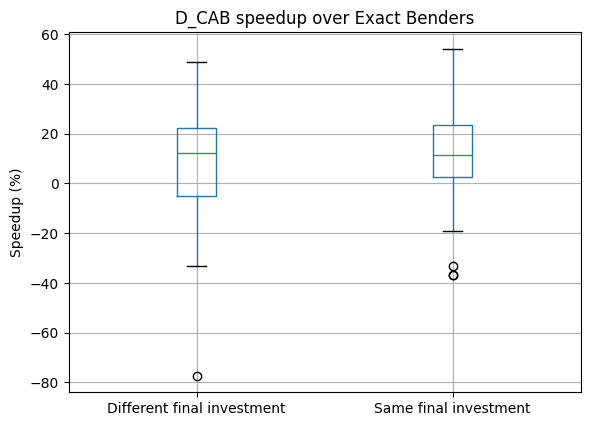

In [ ]:
import matplotlib.pyplot as plt

plot_df = cmp.copy()
plot_df["group"] = plot_df["same_investment"].map({
    True: "Same final investment",
    False: "Different final investment"
})

plt.figure(figsize=(8, 5))
plot_df.boxplot(column="time_speedup_pct", by="group")
plt.suptitle("")
plt.title("D_CAB speedup over Exact Benders")
plt.xlabel("")
plt.ylabel("Speedup (%)")
plt.xticks(rotation=0)
plt.show()

In [166]:
df_dual_gap

,sample_idx,total_demand,total_available,demand_to_total_available,dual_gap_pct,pred_dual_obj,true_dual_obj
0,0,35799.185494,124878.762819,0.286672,4.756148,668.975254,702.381557
1,1,82585.922422,126078.528354,0.655036,239.218787,-225.287086,161.822330
2,2,72575.090225,94659.941670,0.766693,5.396319,521.902364,551.672366
3,3,101728.351386,264047.355442,0.385266,284.016423,-135.108067,73.421744
4,4,114931.397389,230135.406153,0.499408,2.135563,899.409299,919.035890
...,...,...,...,...,...,...,...
3273,3273,78663.381618,70854.401141,1.110212,0.319033,88714.919360,88998.855363
3274,3274,94411.915036,81137.759059,1.163600,0.006858,294353.571412,294373.758842
3275,3275,111539.348361,154911.143682,0.720021,0.027822,303590.078697,303674.568493
3276,3276,126428.709854,97848.254237,1.292090,0.009910,309108.221435,309138.857526


In [167]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_dual_gap_vs_column(
    df,
    x_col,
    y_col="dual_gap_pct",
    title=None,
    xlabel=None,
    log_y=True,
    clip_to_p99=False,
    bins=20,
):
    plot_df = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if clip_to_p99:
        x_hi = plot_df[x_col].quantile(0.99)
        y_hi = plot_df[y_col].quantile(0.99)
        plot_df = plot_df[(plot_df[x_col] <= x_hi) & (plot_df[y_col] <= y_hi)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # scatter
    axes[0].scatter(plot_df[x_col], plot_df[y_col], s=18, alpha=0.45)
    axes[0].set_xlabel(xlabel or x_col)
    axes[0].set_ylabel(y_col)
    axes[0].set_title(title or f"{y_col} vs {x_col}")
    axes[0].grid(True, alpha=0.3)
    if log_y:
        axes[0].set_yscale("log")

    # binned trend
    tmp = plot_df.copy()
    tmp["bin"] = pd.cut(tmp[x_col], bins=bins, duplicates="drop")
    grouped = tmp.groupby("bin", observed=False)

    x_mid = grouped[x_col].median()
    y_mean = grouped[y_col].mean()
    y_median = grouped[y_col].median()

    trend = pd.DataFrame({
        "x_mid": x_mid,
        "y_mean": y_mean,
        "y_median": y_median,
    }).dropna()

    axes[1].plot(trend["x_mid"], trend["y_median"], marker="o", label="Median dual gap")
    axes[1].plot(trend["x_mid"], trend["y_mean"], marker="s", label="Mean dual gap")
    axes[1].set_xlabel(xlabel or x_col)
    axes[1].set_ylabel(y_col)
    axes[1].set_title(f"Binned trend: {y_col} vs {x_col}")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

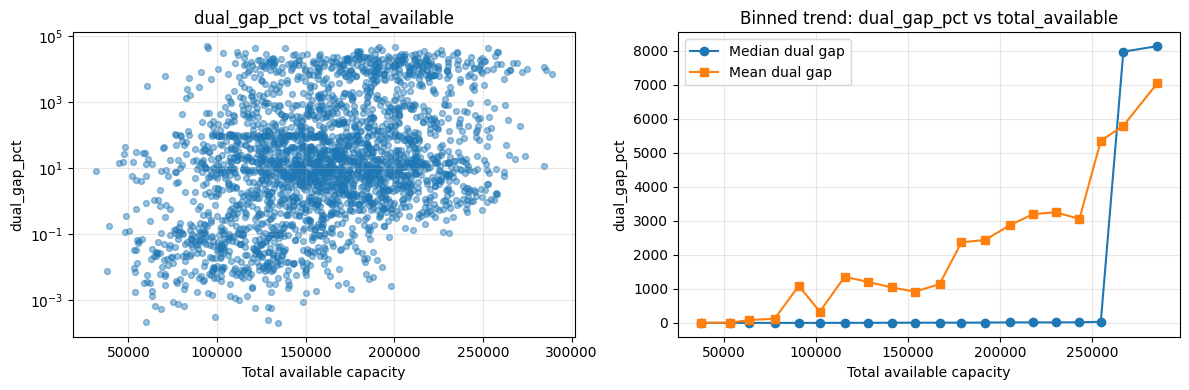

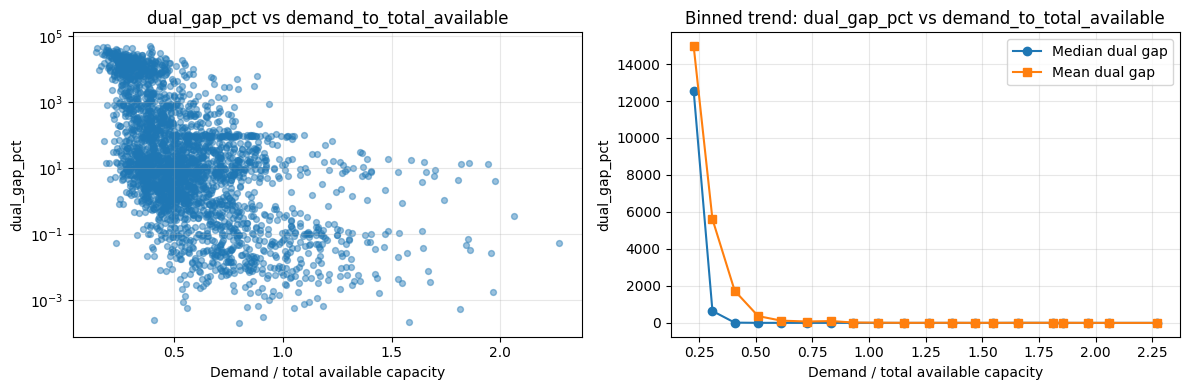

In [168]:
plot_dual_gap_vs_column(
    df_dual_gap,
    x_col="total_available",
    title="dual_gap_pct vs total_available",
    xlabel="Total available capacity",
    log_y=True,
    clip_to_p99=False,
)

plot_dual_gap_vs_column(
    df_dual_gap,
    x_col="demand_to_total_available",
    title="dual_gap_pct vs demand_to_total_available",
    xlabel="Demand / total available capacity",
    log_y=True,
    clip_to_p99=False,
)

In [171]:
import numpy as np

def is_renewable_gen(gen):
    tech = str(gen[1]).lower()
    return tech in {"windon", "windoff", "sunpv", "solar", "wind"}

def add_renewable_availability_columns(df_dual_gap, data):
    X = data.X
    if hasattr(X, "detach"):
        X = X.detach().cpu().numpy()
    else:
        X = np.asarray(X)

    demand_all = X[:, :data.num_n]
    gen_input_all = X[:, data.num_n:data.num_n + data.num_g]

    if "sample_idx" not in df_dual_gap.columns:
        raise ValueError("df_dual_gap must contain a 'sample_idx' column.")

    sample_idx = df_dual_gap["sample_idx"].to_numpy(dtype=int)

    demand = demand_all[sample_idx]
    gen_input = gen_input_all[sample_idx]

    renewable_indices = [i for i, g in enumerate(data.G) if is_renewable_gen(g)]
    renewable_names = [f"{g[0]}_{g[1]}" for g in data.G if is_renewable_gen(g)]

    df = df_dual_gap.copy()

    for idx, name in zip(renewable_indices, renewable_names):
        df[f"availcap_{name}"] = gen_input[:, idx]

    df["renewable_available_total"] = gen_input[:, renewable_indices].sum(axis=1)

    total_demand = demand.sum(axis=1)
    df["renewable_to_total_demand"] = (
        df["renewable_available_total"] / np.maximum(total_demand, 1e-9)
    )

    return df

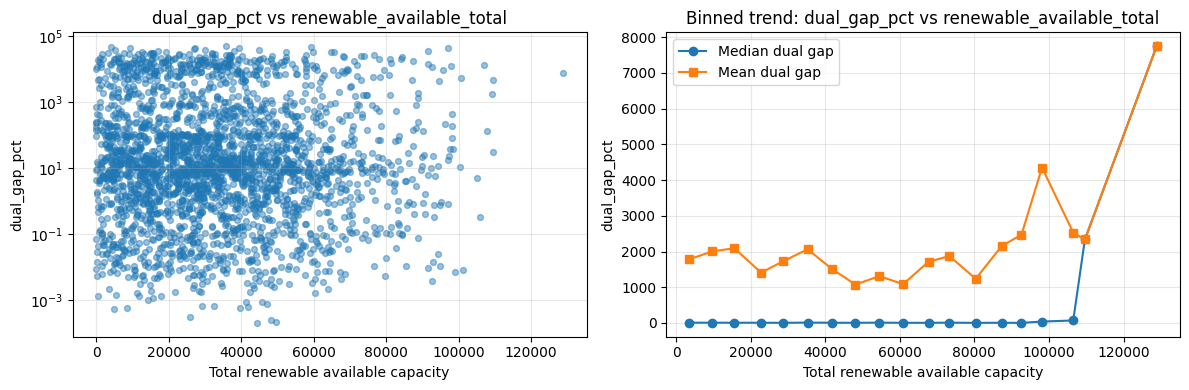

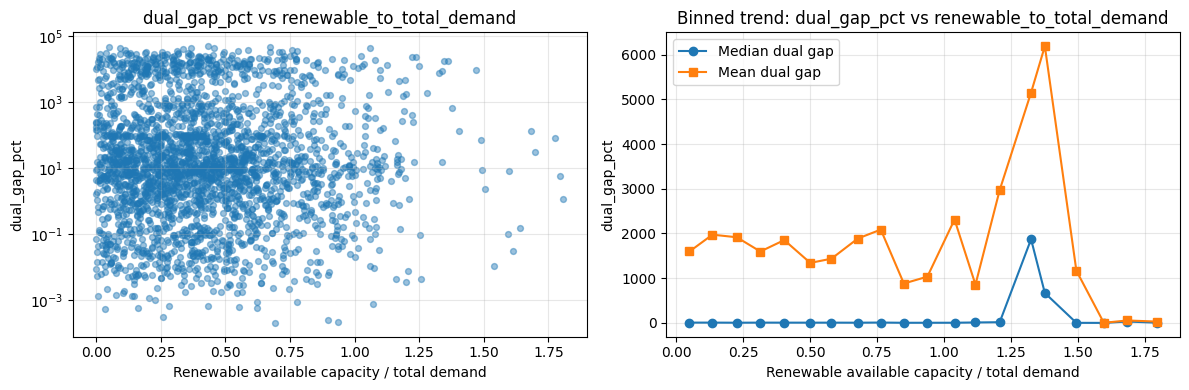

In [172]:
df_dual_gap_ren = add_renewable_availability_columns(df_dual_gap, data)
plot_dual_gap_vs_column(
    df_dual_gap_ren,
    x_col="renewable_available_total",
    title="dual_gap_pct vs renewable_available_total",
    xlabel="Total renewable available capacity",
    log_y=True,
    clip_to_p99=False,
)

plot_dual_gap_vs_column(
    df_dual_gap_ren,
    x_col="renewable_to_total_demand",
    title="dual_gap_pct vs renewable_to_total_demand",
    xlabel="Renewable available capacity / total demand",
    log_y=True,
    clip_to_p99=False,
)